# Inhalt aus: `A000-snippets_ml.ipynb`
---

<p><font size="6" color='grey'> <b>
Machine Learning
</b></font> </br></p>
<p><font size="5" color='grey'> <b>
Snippets
</b></font> </br></p>



---

# 1 | Understand

# 1.1 | Read DataSet

# 1.1.1 | Read OpenML


In [ ]:
data_id = 43406
import pandas as pd
from sklearn.datasets import fetch_openml
df = fetch_openml(parser='auto', target_column='default-target', data_id=data_id)

In [ ]:
data = df.data.copy()
target = df.target.copy()

# 1.1.2 | Read Github

In [ ]:
import pandas as pd
df = pd.read_csv('https://raw.githubusercontent.com/ralf-42/ml-kurs/main/02%20data/BodyPerformance.csv')

In [ ]:
label = 'class'
features = [n for n in df.columns if n != label]

target = df[label].copy()
data = df[features].copy()

# 1.1.3 | Read CSV

In [ ]:
import pandas as pd
filename = ''
df = pd.read_csv(filename, header=0)

In [ ]:
label = 'class'
features = [n for n in df.columns if n != label]

target = df[label].copy()
data = df[features].copy()

# 1.1.4 | Read Excel

In [ ]:
import pandas as pd
filename = ''
df = pd.read_excel(filename)

In [ ]:
label = 'class'
features = [n for n in df.columns if n != label]

target = df[label].copy()
data = df[features].copy()

# 1.1.5 | Read arff

In [ ]:
!uv pip install --system -q liac-arff
import arff
import pandas as pd

def read_arff_file(file_path):
    with open(file_path, 'r') as f:
        data_dict = arff.load(f)
    data = data_dict['data']
    df = pd.DataFrame(data)
    df.columns = [attr[0] for attr in data_dict['attributes']]
    return df

file_path = '/content/phpMYEkMl.arff'
df = read_arff_file(file_path)
print(df.head())

# 1.2 | EDA - Pandas

In [ ]:
data.info()

In [ ]:
data.describe().T

In [ ]:
data.describe(include=object).T

In [ ]:
data.corr(numeric_only=True)

In [ ]:
col_name = ''
data.groupby(col_name).count()

In [ ]:
target.value_counts()

In [ ]:
# _ = data.hist(figsize=(15,15))
# _ = data.plot.scatter(x='length', y='width', c='DarkBlue')
# _ = pd.scatter_matrix(data[features])
# _ = pd.plotting.scatter_matrix(data, alpha=0.2, figsize=[15,15], c='darkblue')
# _ = data.boxplot(column=['age', 'pclass'], figsize=[10,10])

# 1.3 | EDA - Pandas Profiling

In [ ]:
!uv pip install -q --system ydata-profiling

In [ ]:
# Import
import numpy as np
import ydata_profiling
from ydata_profiling.utils.cache import cache_file

In [ ]:
# Bericht erstellen und als html speichern
profile_report = df.profile_report(explorative=True, html={"style": {"full_width": True}})
profile_report.to_file("eda_report.html")
profile_report

# 1.4 | EDA - Plotly

In [ ]:
import plotly.express as px
import plotly.subplots as sp

In [ ]:
# Boxplot
title_ = 'Titel-Text'
px.box(data[['col1', 'col2']], title=title_, width=600, height=600)

In [ ]:
# 3 Boxplots
title_ = 'col1'
box1 = px.box(data['col1'], title=title_, width=600, height=600)

title_ = 'col2'
box2 = px.box(data['col2'], title=title_, width=600, height=600)

title_ = 'col3'
box3 = px.box(data['col2], title=title_, width=600, height=600)

fig = sp.make_subplots(rows=1, cols=3, subplot_titles=('col1', 'col2', 'col3'))

for trace in box1.data:
    fig.add_trace(trace, row=1, col=1)

for trace in box2.data:
    fig.add_trace(trace, row=1, col=2)

for trace in box3.data:
    fig.add_trace(trace, row=1, col=3)

# Layout anpassen
fig.update_layout(width=1000, height=500, title_text='Box-Plots')

# Plot anzeigen
fig.show()'

In [ ]:
# Scattergramm
title_ = 'Titel-Text'
px.scatter(data, x='col1', y='col2', color='target', labels={"col1": "xxxx","col2": "yyyy"}, title=title_, opacity=0.5, width=1200, height=600)

In [ ]:
# Scatter Matrix
# px.scatter_matrix(data, dimensions=data.columns, opacity=0.5, color=target)

In [ ]:
# Linie
px.line(data, x= 'col1', y='col2', width=800, height=400)

# 1.5 | EDA - PyGWalker

In [ ]:
!uv pip install --system -q pygwalker
import pygwalker as pyg

In [ ]:
pyg.walk(data)

# 1.6 | EDA - Yellowbrick

In [ ]:
from yellowbrick.target import class_balance
visualizer = class_balance(target, labels=["A", "B", "C", "D"])

# 1.7 | Write DataSet

In [ ]:
import pandas as pd
from sqlalchemy import create_engine

# Speichern als CSV
data.to_csv("data.csv")

# Speichern als Excel
data.to_excel("data.xlsx")

# Speichern als JSON
data.to_json("data.json")

# Speichern als HTML
data.to_html("data.html")

# Speichern in SQL-Datenbank
engine = create_engine('sqlite:///meine_datenbank.db')
data.to_sql('tabelle_name', con=engine, if_exists='replace')

# Speichern als Parquet
data.to_parquet('data.parquet')

# Speichern als Feather
data.to_feather('data.feather')

# Kopieren in die Zwischenablage
data.to_clipboard()

# Speichern als Markdown (für Dokumentationen geeignet)
data.to_markdown("data.md")

# Speichern als LaTeX (für LaTeX-Dokumente)
data.to_latex("data.tex")

# 2 | Prepare

# 2.1 | Datentypen

# 2.1.1 | Datentyp ermitteln




In [ ]:
all_col = data.columns
num_col = data.select_dtypes(include='number').columns
cat_col = data.select_dtypes(exclude='number').columns

In [ ]:
nom_col = []
ord_col = []

# 2.1.2 | Datentyp ändern

In [ ]:
df['column_name'] = df['column_name'].astype(int)
df['column_name'] = df['column_name'].astype(float)
df['column_name'] = df['column_name'].astype(bool)
df['column_name'] = df['column_name'].astype('string')

# 2.2 | Daten löschen / umbenennen

# 2.2.1 | Spalten löschen

In [ ]:
# Löschen von Spalten
data.drop(['col1', 'col2'], axis='columns', inplace=True)

# 2.2.2 | Spalten umbenennen

In [ ]:
data.rename(columns = {'old_col1':'new_col1', 'old_col2':'new_col2'}, inplace = True)
data.columns = ['new1', 'new2', 'new3', 'new4']
data.columns = data.columns.str.replace('old_char', 'new_char')

# 2.2.3 Zeilen löschen

In [ ]:
data.drop('Zeileninhalt', axis=0)


In [ ]:
# Datensätze mit Wert zwischne 1 und 10 löschen
data_new = data[~(data['col'] > 1) & (data['col'] < 10)].drop()

In [ ]:
# Positivauswahl!
print(data.shape)
data = data[data['sit and bend forward_cm'] <= 150.0]
data = data[data['weight_kg'] > 34]
data = data[data['body fat_%'] < 60]
# Filtern von 'target' basierend auf den verbleibenden Indizes von 'data'
target = target.loc[data.index]
data.shape

In [ ]:
# Negativauswahl!
print(data.shape)
data.drop(data[data['col1'] > 150].index, inplace=True)
data.drop(data[data['col2'] <= 34].index, inplace=True)
# Filtern von 'target' basierend auf den verbleibenden Indizes von 'data'
target = target.loc[data.index]
data.shape

In [ ]:
# Löschen nach der Box-Plot Logik für eine Spalte
import pandas as pd
import numpy as np

column = 'col1'

# Berechne das erste und dritte Quartil (25% und 75% Quantile)
Q1 = data[column].quantile(0.25)
Q3 = data[column].quantile(0.75)

# Berechne den Interquartilsabstand (IQR)
IQR = Q3 - Q1

# Definiere Grenzwerte für Ausreißer
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filtere die Ausreißer heraus und aktualisiere 'data'
data = data[(data[column] >= lower_bound) & (data[column] <= upper_bound)]

# Filtere 'target' basierend auf den verbleibenden Indizes in 'data'
target = target.loc[data.index]

In [ ]:
# Löschen nach der Box-Plot Logik für mehrere Spalten
import pandas as pd
import numpy as np

columns = ['col1', 'col2', 'col3']  # Ersetzen Sie dies mit Ihren Spaltennamen

# Initialisiere einen Filter, der anfangs alle Zeilen als True markiert
filter = pd.Series([True] * len(data), index=data.index)

for column in columns:
    # Berechne das erste und dritte Quartil (25% und 75% Quantile)
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)

    # Berechne den Interquartilsabstand (IQR)
    IQR = Q3 - Q1

    # Definiere Grenzwerte für Ausreißer
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Update den Filter für die aktuelle Spalte
    filter = filter & (data[column] >= lower_bound) & (data[column] <= upper_bound)

# Wende den Filter auf 'data' an
data = data[filter]

# Filtere 'target' basierend auf den verbleibenden Indizes in 'data_filtered'
target = target.loc[data.index]

# 2.3 | Missing Values

# 2.3.1 | Prüfen auf Missing Values

In [ ]:
# --- Berechne die Anzahl der fehlenden Werte pro Spalte
data.isna().sum()

# 2.3.2 | Python Standard

In [ ]:
# --- Entferne Zeilen mit fehlenden Daten
data.dropna(inplace=True)
# --- Ersetze durch Mittelwert, Median, Mode
data['A'].replace([numpy.nan], data['A'].mean(), inplace=True)
data['B'].replace([numpy.nan], data['B'].median(), inplace=True)
data['C'].replace([numpy.nan], data['C'].mode()[0], inplace=True)
# --- Ersetze durch Vorgänger/Nachfolger
data.fillna(method='ffill', inplace=True)
data.fillna(method='bfill', inplace=True)
# --- Ersetze durch Konstante -999
data.fillna(value=-999, inplace=True)


# 2.3.3 | SciKit-Learn

In [ ]:
mv = data.isnull().sum()
mv_col = list(mv[mv > 0].index)

In [ ]:
from sklearn.impute import SimpleImputer
import numpy as np
missing_data = SimpleImputer(missing_values=np.nan, strategy='most_frequent')
data[mv_col] = pd.DataFrame(missing_data.fit_transform(data[mv_col]), columns=mv_col)

# 2.4 | Kodierung & Skalierung

# 2.4.1 | Suchen & Ersetzen

In [ ]:
data.col.replace(['alt'], ['neu'], inplace = True)

# 2.4.2 | Ordinal coder

In [ ]:
# Die Behandlung der resultierenden Kodierung als numerisches Merkmal führt zu einer willkürlich
# geordneten Werten und daher typischerweise zu einer geringeren Vorhersageleistung,
# wenn sie als Vorverarbeitung für einen Klassifikator oder Regressor verwendet wird.
#
from sklearn.preprocessing import Ordinalcoder
data[cat_col] = Ordinalcoder().fit_transform(data[cat_col])

In [ ]:
# Besser ...
from sklearn.preprocessing import Ordinalcoder
cat_seq = [['low', 'medium', 'high'],['first', 'second', 'third']]  # Beispiel mit 2 Sequenzen
data[cat_col] = Ordinalcoder(categories=cat_seq).fit_transform(data[cat_col])

In [ ]:
data.col.replace(['yes', 'no'], [1, 0], inplace = True)

In [ ]:
#@title
#@markdown   <p><font size="4" color='green'>  Bespiel mit Reihenfolge</font> </br></p>
from sklearn.preprocessing import Ordinalcoder

# Angenommen, dies sind Ihre Schulnoten
grades = [['sehr gut'], ['gut'], ['mangelhaft']]

# Erstellen des coders, wobei die Reihenfolge der Noten festgelegt wird
coder = Ordinalcoder(categories=[['sehr gut', 'gut', 'befriedigend', 'ausreichend', 'mangelhaft', 'ungenügend']])

# Anpassen und Transformieren der Daten
ordinal_grades = coder.fit_transform(grades)

print(ordinal_grades)

In [ ]:
#@title
#@markdown   <p><font size="4" color='green'>  Beispiel ohne Reihenfolge</font> </br></p>
from sklearn.preprocessing import Ordinalcoder

# Angenommen, dies sind Ihre Schulnoten
grades = [['sehr gut'], ['gut'], ['mangelhaft']]

# Erstellen des coders, wobei die Reihenfolge der Noten NICHT festgelegt wird
coder = Ordinalcoder()

# Anpassen und Transformieren der Daten
ordinal_grades = coder.fit_transform(grades)

print(ordinal_grades)

# 2.4.3 | Nominal coder

In [ ]:
nom_col = ['Sex','Embarked']
data = pd.concat([data, pd.get_dummies(data, columns=nom_col, prefix_sep='_')], axis='columns')
data.drop(columns=nom_col, inplace=True)

In [ ]:
nom_col = ['Sex','Embarked']
from sklearn.preprocessing import OneHotcoder
ohe = OneHotcoder(sparse_output=False, handle_unknown='ignore')
data = pd.concat([data, pd.DataFrame(ohe.fit_transform(data[nom_col]), columns=ohe.get_feature_names_out())], axis=1)
data.drop(columns=nom_col, inplace=True)

In [ ]:
data.col.replace(['yes', 'no'], [1, 0], inplace = True)

# 2.4.4 |  Target coder (nominal)

In [ ]:
# ab sklearn 1.3.2; aktuell Colab 1.2.2
#
from sklearn.preprocessing import Targetcoder
data[nom_col] = Targetcoder().fit_transform(data[nom_col], target)

In [ ]:
data.col.replace(['yes', 'no'], [1, 0], inplace = True)

# 2.4.5 | Labelcoder

In [ ]:
from sklearn.preprocessing import Labelcoder
target = Labelcoder().fit_transform(target)

In [ ]:
target.replace(['yes', 'no'], [1, 0], inplace = True)

# 2.4.6 | Normalisieren

In [ ]:
from sklearn.preprocessing import MinMaxScaler
data[num_col] = MinMaxScaler().fit_transform(data[num_col])

# 2.4.7 | Standardisieren

In [ ]:
from sklearn.preprocessing import StandardScaler
data[num_col] = StandardScaler().fit_transform(data[num_col])

# 2.4.8 | RobustScaler

In [ ]:
from sklearn.preprocessing import RobustScaler
data[num_col] = RobustScaler ().fit_transform(data[num_col])

# 2.4.9 | C&S Instanzen/Objekte

In [ ]:
all_col = data.columns
num_col = data.select_dtypes(include='number').columns
cat_col = data.select_dtypes(exclude='number').columns

In [ ]:
from sklearn.preprocessing import Ordinalcoder
coder = Ordinalcoder()
data[cat_col] = coder.fit_transform(data[cat_col])

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
data[num_col] = scaler.fit_transform(data[num_col])

In [ ]:
cube[cat_col] = coder.inverse_transform(cube[cat_col])
cube[num_col] = scaler.inverse_transform(cube[num_col])

# 2.5 | Outlier

# 2.5.1 | Outlier via Standardabweichung
Mehr als 3 Standardabweichungen vom Mittelwert entfernt

In [ ]:
# Entferne Datenpunkte, die mehr als 3 Standardabweichungen vom Mittelwert entfernt sind (z-score normalization )
# Dies basiert auf der empirischen Regel (oder 68-95-99,7-Regel), die besagt, dass fast alle Werte (99,7 %)
# innerhalb von drei Standardabweichungen vom Mittelwert einer Normalverteilung liegen.
#
data = data[(abs(data - data.mean()) / data.std() < 3)].drop()
target = target.loc[data.index]

# 2.5.2 |  Outlier via 1.5 IQR (Boxplot)


In [ ]:
# Löschen nach der Box-Plot Logik für eine Spalte
import pandas as pd
import numpy as np

column = 'col1'

# Berechne das erste und dritte Quartil (25% und 75% Quantile)
Q1 = data[column].quantile(0.25)
Q3 = data[column].quantile(0.75)

# Berechne den Interquartilsabstand (IQR)
IQR = Q3 - Q1

# Definiere Grenzwerte für Ausreißer
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filtere die Ausreißer heraus und aktualisiere 'data'
data = data[(data[column] >= lower_bound) & (data[column] <= upper_bound)]

# Filtere 'target' basierend auf den verbleibenden Indizes in 'data'
target = target.loc[data.index]

In [ ]:
# Löschen nach der Box-Plot Logik für mehrere Spalten
import pandas as pd
import numpy as np

columns = ['col1', 'col2', 'col3']  # Ersetzen Sie dies mit Ihren Spaltennamen

# Initialisiere einen Filter, der anfangs alle Zeilen als True markiert
filter = pd.Series([True] * len(data), index=data.index)

for column in columns:
    # Berechne das erste und dritte Quartil (25% und 75% Quantile)
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)

    # Berechne den Interquartilsabstand (IQR)
    IQR = Q3 - Q1

    # Definiere Grenzwerte für Ausreißer
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Update den Filter für die aktuelle Spalte
    filter = filter & (data[column] >= lower_bound) & (data[column] <= upper_bound)

# Wende den Filter auf 'data' an
data = data[filter]

# Filtere 'target' basierend auf den verbleibenden Indizes in 'data_filtered'
target = target.loc[data.index]

# 2.5.3 | Outlier via Winsorizing
Begrenzung min/max auf Grenze 5% und 95% Werte

In [ ]:
from scipy.stats.mstats import winsorize
# Begrenzung der Gültigkeit auf 5% - 95%, Anzahl bleibt erhalten, Werte <5% bzw. >95% werden auf Unter-/Obergrenze gesetzt
data[num_col] = winsorize(data[num_col].values, limits=[0.5, 0.5])
target = target.loc[data.index]

# 2.5.4 | Outlier via LOF

Der LocalOutlierFactor gibt ein Array zurück, in dem -1 für Ausreißer und 1 für Inlier steht.

In [ ]:
from sklearn.neighbors import LocalOutlierFactor

# Erstellen des LocalOutlierFactor-Modells
lof = LocalOutlierFactor(n_neighbors=5)

# Anwenden des Modells auf 'data'
outliers = lof.fit_predict(data[['colname']])  # Stellen Sie sicher, dass 'colname' ein DataFrame ist

# Zählen der Anzahl der Ausreißer
num_outliers = len(outliers[outliers == -1])
print("Anzahl der Ausreißer:", num_outliers)

# Filtere Daten, um nur Inlier zu behalten (outliers == 1)
data = data[outliers == 1]

# Filtere 'target' basierend auf den verbleibenden Indizes in 'data_no_outliers'
target = target.loc[data.index]

# 2.6 | Dimensionen reduzieren

# 2.6.1 | LDA

In [ ]:
# - supervised
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis()
lda_np = lda.fit_transform(data, target)

# Cube um lda erweitern
col_name = [("LDA" + str(i+1)) for i in range(lda_np.shape[1])]
lda_df = pd.DataFrame(lda_np, columns=col_name)
cube = pd.concat([cube, lda_df], axis=1)

In [ ]:
feature_weights = lda.coef_
df_feature_weights = pd.DataFrame(feature_weights,columns=columns, index=['class1', 'class2', ...])
df_feature_weights

In [ ]:
df_dfunction = pd.DataFrame(enumerate(explained_variance_ratios), columns=['Discr.-Function', 'expl. Variance'])
df_dfunction['Discr.-Function'] += 1
df_dfunction

In [ ]:
sum(explained_variance_ratios)

# 2.6.2 | PCA

In [ ]:
# - unsupervised
from sklearn.decomposition import PCA
from sklearn.preprocessing import scale

pca = PCA()
pca_np = pca.fit_transform(scale(data))

# Cube um pca erweitern
col_name = [("PCA" + str(i+1)) for i in range(pca_np.shape[1])]
pca_df = pd.DataFrame(pca_np, columns=col_name)
cube = pd.concat([cube, pca_df], axis=1)

In [ ]:
feature_weights = pca.components_.T
df_feature_weights = pd.DataFrame(feature_weights, columns=col_name, index=data.columns)
df_feature_weights

In [ ]:
df_pcfunction = pd.DataFrame(enumerate(pca.explained_variance_ratio_), columns=['PCA', 'Variance'])
df_pcfunction['PCA'] += 1
df_pcfunction['cum. Variance'] = df_pcfunction['Variance'].cumsum()
df_pcfunction

In [ ]:
sum(explained_variance)

# 2.6.3 | PCA Yellowbrick

In [ ]:
# One-Liner
from yellowbrick.features import pca_decomposition
visualizer = pca_decomposition(data, target)

In [ ]:
# long form
from yellowbrick.features import PCA
viz_pca = PCA()
viz_pca.fit_transform(data, target)
viz_pca.show()

In [ ]:
viz_pca.pca_components_ # Dies gibt Aufschluss über die Größe jedes Merkmals in den Hauptkomponenten

# 2.7 | Imbalanced

# 2.7.1 | Upsampling

In [ ]:
from imblearn.over_sampling import RandomOverSampler
ros = RandomOverSampler(random_state=42)
data_resampled, target_resampled = ros.fit_resample(data, target)

# 2.7.2 | Downsampling

In [ ]:
from imblearn.under_sampling import RandomUnderSampler
rus = RandomUnderSampler(random_state=42)
data_resampled, target_resampled = rus.fit_resample(data, target)

# 2.7.3 | Klassen gewichten

In [ ]:
from sklearn.utils import class_weight
class_weights = class_weight.compute_class_weight('balanced', np.unique(target_train), target_train)
model.fit(data_train, data_train, class_weight=class_weights)


# 2.7.4 | SMOTE
(Synthetic Minority Over-sampling Technique)

In [ ]:
from imblearn.over_sampling import SMOTE
smote = SMOTE()
data_resampled, target_resampled = smote.fit_resample(data, target)

# 2.8 | Duplikate

# 2.8.1 | Duplikate ermitteln

In [ ]:
duplicates = data[data.duplicated()]
print("Anzahl Duplicate: ", len(duplicates))
# print("Duplizierte Einträge:")
# print(duplicates)

# 2.8.2 | Duplikate löschen

In [ ]:
data.drop_duplicates(inplace=True)  # Parameter: subset - column name(s) for duplicate identification

# 2.9 | Data-Split

# 2.9.1 | Train-Test-Split

In [ ]:
from sklearn.model_selection import train_test_split
data_train, data_test, target_train, target_test = train_test_split(data, target, test_size=0.3, random_state=42, stratify=target)
data_train.shape, data_test.shape, target_train.shape, target_test.shape

# 2.9.2 | Train-Val-Test-Split

[train-val-test](https://towardsdatascience.com/how-to-split-data-into-three-sets-train-validation-and-test-and-why-e50d22d3e54c)

In [ ]:
from fast_ml.model_development import train_valid_test_split
data_train, target_train, data_valid, target_valid, data_test, target_test = train_valid_test_split(data, target)

# 2.9.3 | Time-Series-Slices (np.array)

In [ ]:
import numpy as np

def sliding_window_dataset(raw_data, window_size, forecast_horizon):
    dataset = []
    targets = []

    for i in range(len(raw_data) - window_size - forecast_horizon + 1):
        window_slice = raw_data[i:i+window_size, :]
        dataset.append(window_slice)
        target_slice = raw_data[i+window_size:i+window_size+forecast_horizon, :]
        targets.append(target_slice)

    return np.array(dataset), np.array(targets)

def expanding_window_dataset(raw_data, window_size, forecast_horizon):
    dataset = []
    targets = []

    for i in range(window_size, len(raw_data) - forecast_horizon + 1):
        window_slice = raw_data[:i, :]
        dataset.append(window_slice)
        target_slice = raw_data[i:i+forecast_horizon, :]
        targets.append(target_slice)

    return np.array(dataset), np.array(targets)


In [ ]:
raw_data = np.array([[1, 2], [2, 4], [3, 6], [4, 8], [5, 10], [6, 12], [7, 14], [8, 16], [9, 18], [10, 20]])
window_size = 3
forecast_horizon = 2

sliding_dataset, sliding_targets = sliding_window_dataset(raw_data, window_size, forecast_horizon)
expanding_dataset, expanding_targets = expanding_window_dataset(raw_data, window_size, forecast_horizon)

print("Sliding Dataset shape:", sliding_dataset.shape)
print("Sliding Targets shape:", sliding_targets.shape)
print("Expanding Dataset shape:", expanding_dataset.shape)
print("Expanding Targets shape:", expanding_targets.shape)

# 2.9.4 | Time-Series-Slices (DataFrames)

In [ ]:
import numpy as np
import pandas as pd

def sliding_window_dataset(raw_data, window_size, forecast_horizon):
    dataset = []
    targets = []

    for i in range(len(raw_data) - window_size - forecast_horizon + 1):
        window_slice = raw_data.iloc[i:i+window_size]
        dataset.append(window_slice)
        target_slice = raw_data.iloc[i+window_size:i+window_size+forecast_horizon]
        targets.append(target_slice)

    return np.array(dataset), np.array(targets)

def expanding_window_dataset(raw_data, window_size, forecast_horizon):
    dataset = []
    targets = []

    for i in range(window_size, len(raw_data) - forecast_horizon + 1):
        window_slice = raw_data.iloc[:i]
        dataset.append(window_slice)
        target_slice = raw_data.iloc[i:i+forecast_horizon]
        targets.append(target_slice)

    return np.array(dataset), np.array(targets)

In [ ]:
import pandas as pd
import numpy as np

# Create a pandas DataFrame
data = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9], [10, 11, 12], [13, 14, 15]])
df = pd.DataFrame(data, columns=['Feature1', 'Feature2', 'Feature3'])

window_size = 2
forecast_horizon = 1

sliding_dataset, sliding_targets = sliding_window_dataset(df, window_size, forecast_horizon)
expanding_dataset, expanding_targets = expanding_window_dataset(df, window_size, forecast_horizon)

print("Sliding Dataset shape:", sliding_dataset.shape)
print("Sliding Targets shape:", sliding_targets.shape)
print("Expanding Dataset shape:", expanding_dataset.shape)
print("Expanding Targets shape:", expanding_targets.shape)

# 3 | Modeling
---

# 3.1 | Modelle Klassifizierung

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

model = estimator()
model.fit(data_train, target_train)

# 3.2 | Modelle Regression

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

model = estimator()
model.fit(data_train, target_train)

# 3.3 | Modelle Clustering

In [ ]:
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.cluster import AgglomerativeClustering

model = estimator()
model.fit(data, target)

# 3.4 | Modelle Anomaly/Deviation

In [ ]:
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

from pyod.models.knn import KNN
from pyod.models.lof import LOF

model = estimator()
model.fit(data, target)

# 3.5 | Modelle Association

In [ ]:
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules
from mlxtend.frequent_patterns import fpgrowth
from mlxtend.preprocessing import Transactioncoder

model = estimator()
model.fit(data, target)

# 3.6 | Modelle MultiLayerPerceptron

# 3.6.1 | Modelle MultiLayerPerceptron

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.neural_network import MLPRegressor

model = estimator()
model.fit(data, target)

# 3.6.2 | Loss-Entwicklung

In [ ]:
import plotly.express as px
title_ = 'Loss-Entwicklung'
px.line(y=model.loss_curve_, title=title_, labels={'x':'Epochen', 'y':'Loss-Wert'}, width=800, height=400)

# 3.7 | Modelle Ensemble

# 3.7.1 | Bagging

Classification

In [ ]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import BaggingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

# 1. Erzeugen von synthetischen Daten
X, y = make_classification(n_samples=1000, n_features=20, n_informative=15, n_redundant=5, random_state=42)

# 2. Aufteilen in Trainings- und Testdatensatz
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# 3. Erstellen des Bagging-Klassifikators mit MLPClassifier als Basis-Lernmodell
base_estimator = MLPClassifier(random_state=42, max_iter=1000) # Erhöhen der Iterationszahl für bessere Konvergenz
bagging_model = BaggingClassifier(base_estimator=base_estimator, n_estimators=10, random_state=42)

# 4. Trainieren des Modells
bagging_model.fit(X_train, y_train)

# 5. Bewertung des Modells
predictions = bagging_model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)
print(f"Genauigkeit des Bagging-Modells mit MLPClassifier: {accuracy:.2f}")

Regression

In [ ]:
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.ensemble import BaggingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# 1. Erzeugen von synthetischen Regressionsdaten
X, y = make_regression(n_samples=1000, n_features=20, n_informative=10, noise=0.1, random_state=42)

# 2. Aufteilen in Trainings- und Testdatensatz
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# 3. Erstellen des Bagging-Regressors mit LinearRegression als Basis-Lernmodell
base_estimator = LinearRegression()
bagging_regressor = BaggingRegressor(base_estimator=base_estimator, n_estimators=10, random_state=42)

# 4. Trainieren des Modells
bagging_regressor.fit(X_train, y_train)

# 5. Bewertung des Modells
predictions = bagging_regressor.predict(X_test)
mse = mean_squared_error(y_test, predictions)
print(f"Mean Squared Error (MSE) des Bagging-Regressors mit LinearRegression: {mse:.2f}")

# 3.7.2 | Boosting

Classification

In [ ]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 1. Erzeugen von synthetischen Klassifikationsdaten
X, y = make_classification(n_samples=1000, n_features=20, n_informative=2, n_redundant=0, random_state=42)

# 2. Aufteilen in Trainings- und Testdatensatz
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# 3. Erstellen des AdaBoost-Klassifikators mit LogisticRegression als Basis-Lernmodell
base_estimator = LogisticRegression(solver='lbfgs', max_iter=1000)  # Erhöhen der max_iter für bessere Konvergenz
ada_boost_model = AdaBoostClassifier(base_estimator=base_estimator, n_estimators=50, random_state=42, algorithm="SAMME")

# 4. Trainieren des Modells
ada_boost_model.fit(X_train, y_train)

# 5. Bewertung des Modells
predictions = ada_boost_model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)
print(f"Genauigkeit des AdaBoost-Modells mit LogisticRegression: {accuracy:.2f}")

Regression

In [ ]:
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error

# 1. Erzeugen von synthetischen Regressionsdaten
X, y = make_regression(n_samples=1000, n_features=20, n_informative=10, noise=0.1, random_state=42)

# 2. Aufteilen in Trainings- und Testdatensatz
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# 3. Erstellen des AdaBoost-Regressors mit MLPRegressor als Basis-Lernmodell
base_estimator = MLPRegressor(max_iter=1000, random_state=42)  # Erhöhen der max_iter für bessere Konvergenz
ada_boost_regressor = AdaBoostRegressor(base_estimator=base_estimator, n_estimators=50, random_state=42, loss='square')

# 4. Trainieren des Modells
ada_boost_regressor.fit(X_train, y_train)

# 5. Bewertung des Modells
predictions = ada_boost_regressor.predict(X_test)
mse = mean_squared_error(y_test, predictions)
print(f"Mean Squared Error (MSE) des AdaBoost-Regressors mit MLPRegressor: {mse:.2f}")

# 3.7.3 | Stacking

Classification

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier

In [ ]:
estimators = [
    ('rf', RandomForestClassifier(n_estimators=10, random_state=42)),
    ('knn', KNeighborsClassifier()),
    ('svc', make_pipeline(StandardScaler(), LinearSVC(random_state=42)))]

In [ ]:
model = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression())
model.fit(data_train, target_train)

Regression

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.ensemble import StackingRegressor

In [ ]:
estimators = [
    ('rf', RandomForestRegressor(n_estimators=50, max_features=5, max_depth=20, min_samples_leaf=5, random_state=42)),
    ('knn', KNeighborsRegressor(4)),
    ('lreg', LinearRegression())]

In [ ]:
model = StackingRegressor(estimators=estimators, final_estimator=RidgeCV())
model.fit(data_train, target_train)

# 3.8 | HyperparameterTuning

# 3.8.1 | GridSearch

In [ ]:
param_grid = {}
param_grid['param1'] = [10, 50, (10,10,10)]
param_grid['param2'] = ['identity','logistic','relu']
param_grid['param3'] =['lbfgs','sgd','adam']
param_grid['param4'] = ['constant','invscaling','adaptive']

In [ ]:
from sklearn.model_selection import GridSearchCV
gs_cv = GridSearchCV(model, param_grid, cv=2, scoring=['accuracy'],return_train_score= True, verbose=1)

In [ ]:
gs_cv.fit(data_train, target_train)

In [ ]:
gs_cv.best_estimator_
gs_cv.best_params_
gs_cv.best_score_

In [ ]:
gs_cv.cv_results_

In [ ]:
l_mta = list()
l_params = list()

all_results = gs_cv.cv_results_
for mta, params in zip(all_results["mean_test_accuracy"], all_results['params']):
  l_mta.append(mta)
  l_params.append(params)

results = pd.DataFrame(columns=['MTA', 'Parameter'])
results.MTA = l_mta
results.Parameter = l_params
results

# 3.8.2 | RandomizedSearch

In [ ]:
import numpy as np

In [ ]:
param_grid = {}
param_grid['param1'] = np.arange(10, 100, 10)
param_grid['param2'] = np.arange(10, 30, 5)
param_grid['param3'] = np.arange(2, 10, 2)

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
rs_cv = RandomizedSearchCV(estimator = model, param_distributions=param_grid, n_iter=15, cv=5, scoring="r2", verbose=2, random_state=42)
rs_cv.fit(data_test,target_test)

In [ ]:
rs_cv.best_estimator_
rs_cv.best_params_
rs_cv.best_score_

In [ ]:
rs_cv.cv_results_

In [ ]:
l_mts = list()
l_params = list()

all_results = rs_cv.cv_results_
for mts, params in zip(all_results["mean_test_score"], all_results['params']):
  l_mts.append(mts)
  l_params.append(params)

results = pd.DataFrame(columns=['MTS', 'Parameter'])
results.MTS = l_mts
results.Parameter = l_params
results.sort_values(by=['MTS'], ascending=False)

# 3.8.3 | GridSearch Clustering

<p><font color='black' size="4">
Die Verwendung der Scoring-Parameter für GridSearch Clustering haben zu keinen verwertbaren Ergebnissen geführt.
</font></p>

In [ ]:
#@title
#@markdown   <p><font size="4" color='green'>  Benutzerfunktion GridSearch</font> </br></p>
def Custom_GridSearch(model, param_grid, data):
    """
    Erstelle mit ChatGPT
    20.1.2024

    Führt eine manuelle Grid-Suche für ein gegebenes Clustering-Modell und ein Parameter-Grid durch.
    Gibt einen pandas DataFrame mit allen getesteten Parameterkombinationen und deren Scores zurück.

    :param model: Clustering-Modell (z.B. DBSCAN)
    :param param_grid: Dictionary mit Parametern und deren Bereich, die in der Grid-Suche getestet werden sollen
    :param data: Daten, die für das Clustering verwendet werden sollen
    :return: DataFrame mit allen getesteten Parametern und Scores sowie die besten Parameter und den besten Score
    """

    from sklearn.metrics import silhouette_samples, silhouette_score
    import pandas as pd
    import numpy as np
    import itertools

    best_score = -1
    best_params = {}
    results = []

    # Iteriere durch alle Kombinationen der Parameter
    for params in [dict(zip(param_grid, v)) for v in itertools.product(*param_grid.values())]:
        # Aktualisiere Modellparameter
        model.set_params(**params)
        # Anwenden des Modells auf die Daten
        cluster_labels = model.fit_predict(data)

        # Bewertung, wenn mindestens ein Cluster (außer Rauschen) gefunden wurde
        score = -1  # Standardwert für ungültige oder nicht berechenbare Scores
        if len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0) > 1:
            score = silhouette_score(data, cluster_labels)

        # Aktualisiere besten Score und Parameter
        if score > best_score:
            best_score = score
            best_params = params

        # Speichere die aktuellen Ergebnisse
        results.append({**params, 'score': score})

    # Konvertiere Ergebnisse in einen pandas DataFrame
    results_df = pd.DataFrame(results)

    return best_params, best_score, results_df

In [ ]:
param_grid_dbscan = {}
param_grid_dbscan['eps'] = [0.3, 0.5, 0.7]
param_grid_dbscan['min_samples'] = [3, 5, 7, 10]

best_params_dbscan, best_score_dbscan, results_dbscan = Custom_GridSearch(model_dbscan, param_grid_dbscan, data[['Lat', 'Long']])
print(f"Beste Parameter: {best_params_dbscan} und bester Score {best_score_dbscan:0.3f}")

In [ ]:
# results_dbscan

In [ ]:
#  Trainieren des Modells mit den besten Parametern
model_dbscan.set_params(**best_params_dbscan)
model_dbscan.fit(data[['Lat', 'Long']])

# 3.8.4 | KMeans - Elbow

In [ ]:
from yellowbrick.cluster.elbow import kelbow_visualizer
# distortion: mean sum of squared distances to centers
kelbow_visualizer(model_kmeans, data[['Lat', 'Long']], k=(2,7), metric='distortion', timings=False)

In [ ]:
from yellowbrick.cluster.elbow import kelbow_visualizer
# calinski_harabasz: ratio of within to between cluster dispersion
kelbow_visualizer(model_kmeans, data[['Lat', 'Long']], k=(2,7), metric='calinski_harabasz', timings=False)

In [ ]:
from yellowbrick.cluster.elbow import kelbow_visualizer
kelbow_visualizer(model_kmeans, data[['Lat', 'Long']], k=(2,7), metric='silhouette', timings=False, )

# 3.9 | Cross Validation & Bootstrapping

# 3.9.1 | Cross Validation K-Fold

In [ ]:
from sklearn.model_selection import StratifiedKFold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [ ]:
from sklearn.model_selection import KFold
cv = KFold(n_splits=5, shuffle=True, random_state=42)

In [ ]:
from sklearn.model_selection import cross_validate
cv_results = cross_validate(model, data_train, target_train, scoring='r2', cv=cv, return_train_score=True, return_estimator=True)

In [ ]:
# cv_results

In [ ]:
val_result = cv_results['test_score'].mean()
train_result = cv_results['train_score'].mean()
print(f"Train {train_result:.2f} -- Validation {val_result:.2f}")

Datensätze der einzelnen Kreuzvalidierungen

In [ ]:
cv.get_n_splits(data_train)
print(cv)

for i, (train_index, val_index) in enumerate(cv.split(data_train, target_train)):
    print(f"Fold {i}:")
    print(f"  Train: index={train_index[:10]}, count: {len(train_index):,.0f}")
    print(f"  Test:  index={val_index[:10]}, count: {len(val_index):,.0f}")

# 3.9.2 | Cross Validation LOO

In [ ]:
from sklearn.model_selection import LeaveOneOut
loo = LeaveOneOut()

In [ ]:
from sklearn.model_selection import cross_validate
cv_results = cross_validate(model, data_train, target_train, scoring='accuracy', cv=loo, return_train_score=True, return_estimator=True, n_jobs=4, verbose=1)

In [ ]:
# cv_results

In [ ]:
train_result = cv_results['train_score'].mean()
val_result = cv_results['test_score'].mean()
print(f"Train {train_result:.2f} -- Validation {val_result:.2f}")

# 3.9.3 | Cross Validation yellowbrick

In [ ]:
from yellowbrick.model_selection import cv_scores
visualizer = cv_scores(model, data, target, cv=cv, scoring='r2')  # Classification: scoring='f1_weighted'

# 3.9.4 | Bootstrapping

Classification

In [ ]:
import numpy as np

n_bootstrap_samples = 1000 # Empfehlung ist 1000!
bootstrap_accuracy = []

for j in range(n_bootstrap_samples):
    # Ziehen einer Bootstrap-Stichprobe
    bootstrap_indices = np.random.randint(0, len(data), len(data))
    oob_indices = np.array([i for i in range(len(data)) if i not in bootstrap_indices])
    data_bootstrap = data.loc[bootstrap_indices]
    target_bootstrap = target.loc[bootstrap_indices]
    data_oob = data.loc[oob_indices]
    target_oob = target.loc[oob_indices]

    # Modell trainieren
    model.fit(data_bootstrap, target_bootstrap)

    # Modell auf OOB-Daten bewerten
    target_oob_pred = model.predict(data_oob)
    accuracy = accuracy_score(target_oob, target_oob_pred)
    bootstrap_accuracy.append(accuracy)
    if j%100 == 0:
        print(f"Stichprobe: {j:>7,.0f}   Train: {len(bootstrap_indices):>7,.0f}    Val: {len(oob_indices):>7,.0f}")

In [ ]:
# Berechnung des mittleren Accuracy und des Konfidenzintervalls
mean_accuracy = np.mean(bootstrap_accuracy)
conf_interval_80 = np.percentile(bootstrap_accuracy, [10, 90])
conf_interval_95 = np.percentile(bootstrap_accuracy, [2.5, 97.5])
conf_interval_99 = np.percentile(bootstrap_accuracy, [0.5, 0.5])

print(f"Mittlerer Accuracy: {mean_accuracy:.4f}")
print("Konfidenzintervall Accuracy:")
print(f"80% KI/CI: [{conf_interval_80[0]:.4f},  {conf_interval_80[1]:.4f}]")
print(f"95% KI/CI: [{conf_interval_95[0]:.4f},  {conf_interval_95[1]:.4f}]")
print(f"99% KI/CI: [{conf_interval_99[0]:.4f},  {conf_interval_99[1]:.4f}]")

Regression

In [ ]:
import numpy as np

n_bootstrap_samples = 100 # Empfehlung ist 1000!
bootstrap_r2 = []

for j in range(n_bootstrap_samples):
    # Ziehen einer Bootstrap-Stichprobe
    bootstrap_indices = np.random.randint(0, len(data), len(data))
    oob_indices = np.array([i for i in range(len(data)) if i not in bootstrap_indices])
    data_bootstrap = data.loc[bootstrap_indices]
    target_bootstrap = target.loc[bootstrap_indices]
    data_oob = data.loc[oob_indices]
    target_oob = target.loc[oob_indices]

    # Modell trainieren
    model.fit(data_bootstrap, target_bootstrap)

    # Modell auf OOB-Daten bewerten
    target_oob_pred = model.predict(data_oob)
    r2 = r2_score(target_oob, target_oob_pred)
    bootstrap_r2.append(r2)
    if j%10 == 0:
        print(f"Stichprobe: {j:>7,.0f}   Train: {len(bootstrap_indices):>7,.0f}    Val: {len(oob_indices):>7,.0f}")

In [ ]:
# Berechnung des mittleren R² und des Konfidenzintervalls
mean_r2 = np.mean(bootstrap_r2)
conf_interval_80 = np.percentile(bootstrap_r2, [10, 90])
conf_interval_95 = np.percentile(bootstrap_r2, [2.5, 97.5])
conf_interval_99 = np.percentile(bootstrap_r2, [0.5, 0.5])

print(f"Mittlerer R²: {mean_r2:.4f}")
print("Konfidenzintervall R²:")
print(f"80% KI/CI: [untere Grenze {conf_interval_80[0]:.4f}, obere Grenze {conf_interval_80[1]:.4f}]")
print(f"95% KI/CI: [untere Grenze {conf_interval_95[0]:.4f}, obere Grenze {conf_interval_95[1]:.4f}]")
print(f"99% KI/CI: [untere Grenze {conf_interval_99[0]:.4f}, obere Grenze {conf_interval_99[1]:.4f}]")

# 3.A | Pipeline - Full Scope

<p><font color='black' size="5">
Import & Konfiguration Pipeline
</font></p>

In [ ]:
from sklearn.pipeline import Pipeline

In [ ]:
# display models as diagrams
from sklearn import set_config
set_config(display='diagram')

<p><font color='black' size="5">
Datentyp ermitteln
</font></p>

In [ ]:
all_col = data.columns
num_col = data.select_dtypes(include='number').columns
cat_col = data.select_dtypes(exclude='number').columns

<p><font color='black' size="5">
Missing Values & Kodierung - Pipeline für kategoriale Features
</font></p>

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import Ordinalcoder

cat_pipe = Pipeline([
    ('cat_imputer', SimpleImputer(strategy='most_frequent')),
    ('coder', Ordinalcoder(unknown_value=999, handle_unknown='use_encoded_value'))
    ])

<p><font color='black' size="5">
Missing Values & Skalierung - Pipeline für numerische Features
</font></p>

In [ ]:
from sklearn.preprocessing import StandardScaler
num_pipe = Pipeline([
    ('num_imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
    ])

<p><font color='black' size="5">
Verbinden der beiden Pipelines zu einem ColumnTransformer (parallele Verarbeitung)
</font></p>

In [ ]:
from sklearn.compose import ColumnTransformer
prepare_pipe = ColumnTransformer(transformers=[
      ('categorical', cat_pipe, cat_col),
      ('numerical', num_pipe, num_col)
      ])

<p><font color='black' size="5">
Train-Test-Split
</font></p>


In [ ]:
from sklearn.model_selection import train_test_split
data_train, data_test, target_train, target_test = train_test_split(data, target, test_size=0.30, shuffle=True, random_state=42)
data_train.shape, data_test.shape, target_train.shape, target_test.shape

 <p><font color='black' size="5">
Modellauswahl, Verbinden Prepare- & Model-Pipeline, Training
</font>

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.feature_selection import SelectKBest, f_regression, mutual_info_regression

In [ ]:
model = Pipeline([
                  ('prepare', prepare_pipe),
                  ('feature_selection', SelectKBest(score_func=f_regression, k=6)),
                  ('tree', DecisionTreeRegressor(max_depth=4, min_samples_split=50)) ])

In [ ]:
model.fit(data_train, target_train)


<p><font color='black' size="5">
Analyse von Zwischenschritten einer Pipeline
</font></p>

In [ ]:
 # Konfiguration Pipeline 'prepare'
 model.named_steps.prepare

In [ ]:
# Mittelwerte der skalierten Features
pipe_prepare.named_transformers_['numerical'].named_steps['scaler'].mean_

In [ ]:
# Namen der 4 ausgewählten Features - in der Pipeline werden die Column-Names nicht durchgereicht!
model.named_steps['feature_selection'].get_feature_names_out()

In [ ]:
# Überführen in Column-Names
feature_index = model.named_steps['feature_selection'].get_feature_names_out()
index = [int(i[1:]) for i in feature_index]
feature_ = data.columns[index]
feature_

In [ ]:
# Anzahl der in DecisionTreeRegression verwendeten Features
model.named_steps['tree'].n_features_in_

# 4 | Evaluate
---

# 4.1 | Modellgüte Klassifikation

# 4.1.1 | Prognose

In [ ]:
target_train_pred = model.predict(data_train)
target_test_pred = model.predict(data_test)

In [ ]:
# Prognose 2 neue Datensätze an das Modell übergeben
# new_data = { 'feat1': [1, 2], 'feat2': [0, 1], 'feat4': [33, 80], 'feat5': [0, 0], 'feat6': [0, 0] }
# new = pd.DataFrame(new_data)
# model.predict(new)

# 4.1.2 | Accuracy

In [ ]:
from sklearn.metrics import accuracy_score
acc_train = accuracy_score(target_train, target_train_pred) * 100
print (f"Modell: {model} -- Train -- Accuracy: {acc_train:5.2f}")

In [ ]:
acc_test = accuracy_score(target_test, target_test_pred) * 100
print (f"Modell: {model} -- Test -- Accuracy: {acc_test:5.2f}")

# 4.1.3 | Precision, Recall, F1-Score

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score
precision = precision_score(target_test, target_test_pred)
recall = recall_score(target_test, target_test_pred)
f1 = f1_score(target_test, target_test_pred)

print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

# 4.1.4 | Confusion Matrix

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
conf_matrix = confusion_matrix(target_test, target_test_pred)
display_labels_=['No','Yes']
disp = ConfusionMatrixDisplay(conf_matrix, display_labels=display_labels_)
disp.plot(cmap='Blues')

In [ ]:
print(classification_report(target_test, target_test_pred, target_names=display_labels_))

# 4.1.5 | Cohen's Kappa

In [ ]:
from sklearn.metrics import cohen_kappa_score
target_pred = model.predict(data_train)
cks_train = cohen_kappa_score(target_train, target_pred)
print (f"Modell: {model} -- Train -- Cohen's Kappa: {cks_train:5.2f}")

# 4.1.6 | ROC/AUC

Yellowbrick

In [ ]:
from yellowbrick.classifier.rocauc import roc_auc
roc_auc(model, X_train=data, y_train=target, X_test=data, y_test=target, micro=False, macro=False, classes=['No', 'Yes'])

Scikit-Learn

In [ ]:
from sklearn.metrics import roc_auc_score
roc_auc_score(target, target_pred)

In [ ]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

RocCurveDisplay.from_predictions(target_test, target_test_pred_prob)
plt.title('ROC-AUC Kurve')
plt.show()

# 4.1.7 | Discrimination Threshold


In [ ]:
# --- Quick Version mit Fehler
# from yellowbrick.classifier.threshold import discrimination_threshold
# discrimination_threshold(model, data, target)

In [ ]:
from yellowbrick.classifier import DiscriminationThreshold
# Instantiate the classification model and visualizer
visualizer = DiscriminationThreshold(model, random_state=42, n_trials=1 , exclude="queue_rate")
visualizer.fit(data_test, target_test, random_state=42)
visualizer.show()

SciKit-Learn

In [ ]:
proba_all = model.predict_proba(data_test)

In [ ]:
threshold = 0.45
new_target_pred = (proba_all['True_Fall']>= threshold).astype(int)
conf_matrix = confusion_matrix(target_test, new_target_pred)
disp = ConfusionMatrixDisplay(conf_matrix, display_labels=['No','Yes'])
disp.plot(cmap='Blues')

# 4.1.8 | Class Prediction Error

In [ ]:
from yellowbrick.classifier import class_prediction_error
classes = ["A", "B", "C", "D", "E"]
class_prediction_error(model,data_train, target_train, data_test, target_test, classes=classes)

# 4.1.9 | TPR & FPR

In [ ]:
from sklearn.metrics import confusion_matrix
tn, fp, fn, tp = confusion_matrix(target_test, target_test_pred).ravel()
tpr = tp / (tp + fn)
fpr = fp / (fp + tn)

print("True Positive Rate (TPR):", tpr)
print("False Positive Rate (FPR):", fpr)


# 4.2. | Modellgüte Regression

# 4.2.1 | Prognose

In [ ]:
target_train_pred = model.predict(data_train)
target_test_pred = model.predict(data_test)

In [ ]:
# Prognose 2 neue Datensätze an das Modell übergeben
# new_data = { 'feat1': [1, 2], 'feat2': [0, 1], 'feat4': [33, 80], 'feat5': [0, 0], 'feat6': [0, 0] }
# new = pd.DataFrame(new_data)
# model.predict(new)

# 4.2.2 | Bestimmtheitsmass - r2

In [ ]:
from sklearn.metrics import r2_score
r2_train = r2_score(target_train, target_train_pred)
print(f'Modell: {model}\n -- Train -- Bestimmtheitsmass: {r2_train:5.2f}' )

In [ ]:
r2_test = r2_score(target_test, target_test_pred)
print(f'Modell: {model}\n -- Test -- Bestimmtheitsmass: {r2_test:5.2f}' )

# 4.2.3 | Mean Absolut Error - MAE

In [ ]:
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(target_test, target_test_pred)
print(f'Modell: {model} -- Test -- Mean Absolute Error: {mae:5.2f}' )

# 4.2.4 | Regressionskoeffizienten

In [ ]:
print('Intercept/Ursprung: %10.2f' %float(model.intercept_))
anzahl = len(model.coef_)
print(f'Slope/Steigung der {anzahl} Merkmale: \n ', model.coef_)

# 4.2.5 | Residuals Plot

In [ ]:
from yellowbrick.regressor import residuals_plot
_ = residuals_plot(model, data_train, target_train, data_test, target_test)

In [ ]:
def erstelle_residuals_plot(target, prediction):
    # Berechne die Residuen
    residuals = prediction - target

    # Erstelle ein DataFrame für die Visualisierung
    df = pd.DataFrame({
        'Prediction': prediction,
        'Residuals': residuals
    })

    # Erstelle den Residuals Plot
    fig = px.scatter(df, x='Prediction', y='Residuals',
                     title='Residuals Plot',
                     labels={'Prediction': 'Vorhergesagte Werte', 'Residuals': 'Residuen'},
                     marginal_y='histogram')

    fig.update_layout(width=1000, height=600)

    # Zeige den Plot an
    fig.show()

erstelle_residuals_plot(target_test, target_test_pred.flatten())

# 4.2.6 | Prediction Error

In [ ]:
from yellowbrick.regressor import prediction_error
_ = prediction_error(model, data_test, target_test)

# 4.2.7 | f_regression

In [ ]:
from sklearn.feature_selection import f_regression
fscores, pvalues = f_regression(data_test, target_test)
for i in range(len(fscores)):
    print(f"Feature {i+1}: {data.columns[i]:10s} score = {fscores[i]:>12,.2f}, p-value = {pvalues[i]:.3f}")

In [ ]:
import plotly.express as px
px.bar(x=fscores, y=data.columns, width=600, height=600).update_yaxes(categoryorder="total ascending")

# 4.3 | Residuenanalyse

# 4.3.1a | Aufbau Analysewürfel

In [ ]:
# Übernahme der Testdaten
cube = data_test.copy()
cube.reset_index(inplace=True)

# Übernahem Target real & predict
cube['real'] = pd.DataFrame(target_test.values, columns=['real'])
cube['predict'] = pd.DataFrame(target_test_pred, columns=['predict'])

In [ ]:
# Erstellung 2D Features über Dimensionsreduktion PCA - unsupervised
from sklearn.decomposition import PCA
from sklearn.preprocessing import scale

pca = PCA(n_components=2)
pca_np = pca.fit_transform(scale(data_test))
pca_df = pd.DataFrame(pca_np)

# Cube um pca erweitern
col_name = [("PCA" + str(i+1)) for i in range(pca_np.shape[1])]
pca_df = pd.DataFrame(pca_np, columns=col_name)
cube = pd.concat([cube, pca_df], axis=1)

# 4.3.1b | Aufbau Analysewürfe (proba)

In [ ]:
# Übernahme der Testdaten
cube = data_test.copy()
cube.reset_index(inplace=True)

# Übernahem Target real & predict
cube['real_no'] = pd.DataFrame(target_test[:,0], columns=['real_no'])
cube['real_yes'] = pd.DataFrame(target_test[:,1], columns=['real_yes'])
cube['predict_no'] = pd.DataFrame(target_test_pred[:,0], columns=['predict_no'])
cube['predict_yes'] = pd.DataFrame(target_test_pred[:,1], columns=['predict_yes'])

cube['real'] = cube['real_yes']
cube['predict'] = round(cube['predict_yes'])

In [ ]:
# Erstellung 2D Features über Dimensionsreduktion PCA - unsupervised
from sklearn.decomposition import PCA
from sklearn.preprocessing import scale

pca = PCA(n_components=2)
pca_np = pca.fit_transform(scale(data_test))
pca_df = pd.DataFrame(pca_np)

# Cube um pca erweitern
col_name = [("PCA" + str(i+1)) for i in range(pca_np.shape[1])]
pca_df = pd.DataFrame(pca_np, columns=col_name)
cube = pd.concat([cube, pca_df], axis=1)

# 4.3.2 | Visualisierung real vs predict


In [ ]:
import plotly.express as px
import plotly.subplots as sp

In [ ]:
# Boxplot
title_ = 'Boxplot real vs predict'
px.box(cube[['real', 'predict']], title=title_, width=600, height=600)

In [ ]:
# Histogramm - Variante 1
title_ = 'Histogramm real vs predict'
fig = px.histogram(cube, x=['real', 'predict'], text_auto=".2s", nbins=2, title=title_)
fig.update_layout(barmode='group',bargap=0.1, width=800, height=600)
fig.show()

In [ ]:
# Histogramm - Variante 2
title_ = 'Histogramm absolute Abweichung'
fig = px.histogram(cube, x=['abs_Abw%'], text_auto=".2s", title=title_)
fig.update_layout(barmode='group',bargap=0.2, width=800, height=600)

fig.update_traces(xbins=dict( # bins used for histogram
        start=0.0,
        end=80.0,
        size=2
    ))
fig.show()

In [ ]:
# 2 x Scatterplots

# cube['real_cat'] = cube['real'].astype(str)
# cube['predict_cat'] = cube['predict'].astype(str)

# Farbzuteilung für Kategoriewerte
color_mapping = {'0': 'red', '1': 'blue'}

img1 = px.scatter(cube, x='PCA1', y='PCA2', color='real', color_discrete_map=color_mapping, width=600, height=600)
img2 = px.scatter(cube, x='PCA1', y='PCA2', color='predict', color_discrete_map=color_mapping, width=600, height=600)

fig = sp.make_subplots(rows=1, cols=2, subplot_titles=('Scatterplot real', 'Scatterplot predict'))

for trace in img1.data:
    fig.add_trace(trace, row=1, col=1)

for trace in img2.data:
    fig.add_trace(trace, row=1, col=2)

# Layout anpassen
title_ = 'Streupunktdiagramm ...'
fig.update_layout(width=1000, height=500, title_text=title_)

# Plot anzeigen
fig.show()

In [ ]:
# Matching Mehr-Klassenzuordnung (nicht binär)
import plotly.express as px

title_ = 'Streupunktdiagramm Klassen real vs predict'
# Berechnen der Anzahl von x=y
cube['count'] = cube.groupby(['real', 'predict'])['real'].transform('count')

# Erstellen des Scatterplots mit Größe der Punkte abhängig von der Anzahl von x=y
fig = px.scatter(cube, x='real', y='predict', size='count', width=700, height=700)

# Anpassen der Größe der Punkte im Scatterplot
fig.update_traces(marker=dict(sizemode='area', sizeref=0.7))

# Anzeigen des Scatterplots
fig.show()

In [ ]:
from yellowbrick.regressor import residuals_plot
viz = residuals_plot(model, data_train, target_train, data_test, target_test)

# 4.3.3 | Fehlerhafte Vorhersagen (cat)


In [ ]:
# real <> predict
cube[cube.real != cube.predict].describe().T

In [ ]:
cube[cube.real != cube.predict]

# 4.3.4 | Fehlerhafte Vorhersagen (num)

In [ ]:
cube['abs_Abw%'] = abs((cube['real'] - cube['predict']) / cube['real'] *100)
%precision 3
cube.head(10).style.format("{:,.1f}")

In [ ]:
# Histogramm - Variante 1
title_ = 'Histogramm absolute Abweichung'
fig = px.histogram(cube, x=['abs_Abw%'], text_auto=".2s", nbins=20, title=title_)
fig.update_layout(barmode='group',bargap=0.2, width=800, height=600)
fig.show()

In [ ]:
# Histogramm - Variante 2
title_ = 'Histogramm absolute Abweichung'
fig = px.histogram(cube, x=['abs_Abw%'], text_auto=".2s", title=title_)
fig.update_layout(barmode='group',bargap=0.2, width=800, height=600)

fig.update_traces(xbins=dict( # bins used for histogram
        start=0.0,
        end=80.0,
        size=2
    ))
fig.show()

# 4.3.5 | Einzelne Vorhersage


In [ ]:
# 2 neue Datensätze werden zur Prognose an das Modell übergeben: Rose & Jack
new_data = { 'pclass': [1, 3], 'sex': [1, 0], 'age': [22, 23], 'sibsp': [0, 0], 'parch': [0, 0] }
new = pd.DataFrame(new_data)

In [ ]:
# Vorhersage erstellen Rose & Jack
model.predict(new)

# 4.3.6 | Residuals Plot (Regression)

In [ ]:
from yellowbrick.regressor import residuals_plot
_ = residuals_plot(model, data_train, target_train, data_test, target_test)

In [ ]:
def erstelle_residuals_plot(target_train, target_train_pred, target_test, target_test_pred, title):
    """Erstellt Residuals Plot mit Train/Test Split"""
    # Arrays zu 1D konvertieren
    target_train = np.array(target_train).ravel()
    target_train_pred = np.array(target_train_pred).ravel()
    target_test = np.array(target_test).ravel()
    target_test_pred = np.array(target_test_pred).ravel()

    df_train = pd.DataFrame({
        'Vorhersage': target_train_pred,
        'Residuen': target_train_pred - target_train,
        'Set': 'Train'
    })

    df_test = pd.DataFrame({
        'Vorhersage': target_test_pred,
        'Residuen': target_test_pred - target_test,
        'Set': 'Test'
    })

    df = pd.concat([df_train, df_test])

    fig = px.scatter(df, x='Vorhersage', y='Residuen',
                    color='Set',
                    color_discrete_map={'Train': 'blue', 'Test': 'green'},
                    opacity=0.5,  # Transparenz hinzugefügt
                    title=title,
                    labels={'Vorhersage': 'Vorhergesagte Werte',
                           'Residuen': 'Residuen'},
                    marginal_y='histogram',
                    width=1000,   # Breite in Pixeln
                    height=600)

    fig.add_hline(y=0, line_color="black")
    fig.update_layout(height=600, margin=dict(t=100))
    fig.update_layout(
        xaxis=dict(domain=[0, 0.85]),  # Scatter nimmt 85% der Breite ein
        xaxis2=dict(domain=[0.86, 1]),
        title='Häufigkeit'
        )

    return fig

erstelle_residuals_plot(target_train, target_train_pred, target_test, target_test_pred, "Residual Plot")

# 4.4 | Modellgüte Clustering & Anomalie

# 4.4.1 | Silhouette Koeffizient inkl. plot

In [ ]:
# sklearn - Silhouette Koeffizient gesamt
from sklearn.metrics import silhouette_score
silhouette_coef = silhouette_score(data, model.labels_)
print("Silhouette-Koeffizient:", silhouette_coef)

In [ ]:
# sklearn - Silhouette Koeffizent je Datensatz
from sklearn.metrics import silhouette_samples
silhouette_vals = silhouette_samples(data[['Lat', 'Long']], model.labels_)
silhouette_vals

In [ ]:
# sklearn - Silhouette Koeffizent je Cluster
import numpy as np
unique_clusters = np.unique(model.labels_)
for cluster in unique_clusters:
    if cluster != -1: # Ausreißer ignorieren
        cluster_avg_silhouette = np.mean(silhouette_vals[model.labels_ == cluster])
        print(f"Cluster {cluster}: ∅ Silhouettenkoeffizient = {cluster_avg_silhouette:.3f}")

In [ ]:
#@title
#@markdown   <p><font size="4" color='green'>  Benutzerdefinierte Funktion Plot Silhouette Koeffizient</font> </br></p>
#
# Erstellt mit ChatGPT
# 20.1.2024
#
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

def plot_silhouette_coefficients(silhouette_values, cluster_labels):
    n_clusters = len(np.unique(cluster_labels))
    y_lower = -10

    # Erstellen eines neuen Plots
    plt.figure(figsize=(7, 5))

    # Setzen der Limits für den Plot
    plt.xlim([-0.1, 1])
    plt.ylim([0, len(silhouette_values) + (n_clusters + 1) * 10])

    for i in range(n_clusters):
        # Extrahieren der Silhouettenwerte für diesen Cluster
        ith_cluster_silhouette_values = silhouette_values[cluster_labels == i]
        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        plt.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhouette_values, facecolor=color, edgecolor=color, alpha=0.7)

        # Beschriftung der Silhouettenplots mit ihren Clusternummern in der Mitte
        plt.text(-0.5, y_lower + 0.5 * size_cluster_i, str(i))

        y_lower = y_upper + 10  # 10 für die Lücke zwischen den Clustern

    plt.title("Silhouettenplot für die verschiedenen Cluster")
    plt.xlabel("Silhouettenkoeffizient")
    plt.ylabel("Cluster")

    # Durchschnittlicher Silhouettenwert für alle Cluster
    silhouette_avg = np.mean(silhouette_values)
    plt.axvline(x=silhouette_avg, color="red", linestyle="--")

    # Anzeige des durchschnittlichen Silhouettenkoeffizienten für jeden Cluster
    for i in range(n_clusters):
        cluster_silhouette_values = silhouette_values[cluster_labels == i]
        cluster_silhouette_avg = np.mean(cluster_silhouette_values)
        plt.text(silhouette_avg * 1.1, i * 10 + 20, f"Cluster {i} - {cluster_silhouette_avg:.3f}", color="red")

    # Hinzufügen des Gesamtsilhouettenkoeffizienten an der roten Linie
    plt.text(silhouette_avg + 0.1, y_lower + 5, f"Gesamtsilhouette: {silhouette_avg:.3f}", color="blue")

    plt.yticks([])  # Y-Achsen-Beschriftungen entfernen
    plt.xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

    plt.tight_layout()  # Mehr Platz für die Beschriftung
    plt.show()

# Beispielaufruf der Funktion
# plot_silhouette_coefficients(silhouette_values, cluster_labels)


In [ ]:
plot_silhouette_coefficients(silhouette_vals, model.labels_)

# 4.4.2 | Silhouette Koeffizient - Yellowbrick

In [ ]:
from yellowbrick.cluster import SilhouetteVisualizer
visualizer = SilhouetteVisualizer(model_kmeans, colors='yellowbrick')
visualizer.fit(data)
visualizer.show()

In [ ]:
visualizer.silhouette_samples_       # Silhouette Koeffizent je Datensatz
visualizer.silhouette_score_         # Silhouette Koeffizient gesamt
visualizer.y_tick_pos_               # Die berechneten Mittelpunktpositionen jedes Clusters auf der y-Achse

In [ ]:
from yellowbrick.cluster import intercluster_distance
vis2 = intercluster_distance(model_kmeans, data)

In [ ]:
vis2.scores_ # Anzahl Datensätze im Cluster

# 4.4.3 | Davies-Bouldin-Index

In [ ]:
from sklearn.metrics import davies_bouldin_score
db_index = davies_bouldin_score(data, model.labels_)

# 4.4.4 | Homogenität & Vollständigkeit

In [ ]:
from sklearn.metrics import homogeneity_score, completeness_score
homogeneity = homogeneity_score(target, target_pred)
completeness = completeness_score(target, target_pred)
print("Homogenität:", homogeneity)
print("Vollständigkeit:", completeness)

# 4.4.5 | Anomalie-Koeffizient

In [ ]:
# Initialisiere und trainiere den IsolationForest
# model = IsolationForest(n_estimators=100, contamination='auto', random_state=0)
# model.fit(data)
# Berechne Anomalie-Scores (je höher, desto anomalier)
anomaly_scores = model.decision_function(data)

# 4.5 | Feature Importance/Selection

# 4.5.1 | Feature Importance Tree


In [ ]:
import plotly.express as px
px.bar(x=model.feature_importances_, y=data.columns, text_auto=".2s", title='Feature Importance', width=800, height=500).update_yaxes(categoryorder="total ascending")

# 4.5.2 | Feature Importance Regression


In [ ]:
from sklearn.feature_selection import f_regression
fscores, pvalues = f_regression(data_test, target_test)
for i in range(len(fscores)):
    print(f"Feature {i+1}: {data.columns[i]:10s} score = {fscores[i]:>12,.2f}, p-value = {pvalues[i]:.3f}")

In [ ]:
import plotly.express as px
px.bar(x=fscores, y=data.columns, text_auto=".2s", title='Feature Importance', width=600, height=600).update_yaxes(categoryorder="total ascending")

# 4.5.3 | Feature Importance yellowbrick

In [ ]:
from yellowbrick.model_selection import feature_importances
_ = feature_importances(model, data, target)

# 4.5.4 | SelectKBest

In [ ]:
# Variante 1: Aufbau eines data_selected
# ---
# Die Wahl zwischen chi2 (kategorisch) und f_regression (numerisch) hängt von der Art der Zielvariable ab
# from sklearn.feature_selection import SelectKBest, chi2, f_regression
# k_best = SelectKBest(score_func=chi2, k=3)

from sklearn.feature_selection import SelectKBest

# Anwendung von SelectKBest
selector = SelectKBest(k=2)
data_selected = selector.fit_transform(data, target)

# Print Column-Name Selected Features
feature_indices = selector.get_support(indices=True)
feature_names = data.columns[feature_indices]
print("Selected features:", feature_names)

# Training des RandomForestRegressor
model = RandomForestRegressor()
model.fit(data_train_selected, target_train_selected)

# Vorhersagen mit dem Modell
target_test_pred = model.predict(data_test_selected)


In [ ]:
# Variante 2: Selektion ausgewählter Spalten via Spaltenindex
# ---
# Die Wahl zwischen chi2 (kategorisch) und f_regression (numerisch) hängt von der Art der Zielvariable ab
# from sklearn.feature_selection import SelectKBest, chi2, f_regression
# k_best = SelectKBest(score_func=chi2, k=3)

from sklearn.feature_selection import SelectKBest

# Anwendung von SelectKBest
selector = SelectKBest(k=2)
selector.fit(data, target)

# Column-Name Selected Features
# feature_indices = selector.get_support(indices=True)
# feature_names = data.columns[feature_indices]
feature_names = selector.get_feature_names_out()


# Training des RandomForestRegressor
model = RandomForestRegressor()
model.fit(data_train[feature_names], target_train)

# Vorhersagen mit dem Modell
target_test_pred = model.predict(data_test[feature_names])

# 4.5.5 | Recursive Feature Elimination
sklearn

In [ ]:
from sklearn.feature_selection import RFE
rfe = RFE(estimator=model, n_features_to_select=1)
rfe.fit(X, y)
feature_ranking = rfe.ranking_
feature_names = data.columns
for rank, name in sorted(zip(feature_ranking, feature_names)):
    print(f'Feature "{name}" has rank {rank}')

# 4.5.6 | Recursive Feature Elimination
yellowbrick

In [ ]:
from sklearn.model_selection import StratifiedKFold
from yellowbrick.model_selection import rfecv
cv = StratifiedKFold(5)
visualizer = rfecv(model, X=data, y=target, cv=cv, scoring='f1_weighted') # Regression: scoring='r2'

In [ ]:
visualizer.support_, visualizer.ranking_, visualizer.cv_scores_

# 4.6 | Modellinterpretation allgemein


# 4.6.1 | Tree - Regeln/Text

In [ ]:
from sklearn.tree import export_text
# tree_rules = export_text(model, feature_names=list(model.feature_names_in_), class_names=display_labels_, spacing=7, decimals=1,  show_weights=True)
tree_rules = export_text(model, feature_names=list(model.feature_names_in_), spacing=7, decimals=1,  show_weights=True)
print(tree_rules)

# 4.6.2 | Tree visual - dtreeviz

In [ ]:
!uv pip install --system -q dtreeviz

In [ ]:
viz_model = dtreeviz.model(model, data, target, target_name="target", class_names=display_labels_, feature_names=data.columns)

In [ ]:
viz_model.view(scale=1.0, fontname='Monospace')

In [ ]:
viz_model.view(scale=1.2, orientation="LR", fontname='Monospace')

In [ ]:
# local Explanation
one = data_test.iloc[13]
viz_model.view(x=one, fontname='Monospace')

In [ ]:
# local Explanation
viz_model.view(x=one, show_just_path=True, fontname='Monospace')

In [ ]:
tree_img = viz_model.view(scale=0.8, fontname='Monospace')
tree_img.save('tree.svg')

# 4.6.3 | Tree visual - graphviz

In [ ]:
import graphviz
from sklearn import tree
# DOT data
dot_data = tree.export_graphviz(model, out_file=None, feature_names=data.columns, class_names=display_labels_, filled=True)

# Draw graph
graph = graphviz.Source(dot_data, format="png")
graph

# 4.7 | Verschiedenes

# 4.7.1 | Discrimination Threshold


In [ ]:
from yellowbrick.classifier import DiscriminationThreshold
# Instantiate the classification model and visualizer
visualizer = DiscriminationThreshold(model, random_state=42, n_trials=1 , exclude="queue_rate")
visualizer.fit(data_test, target_test, random_state=42)
visualizer.show()

In [ ]:
# --- Quick Version mit Fehler
# from yellowbrick.classifier.threshold import discrimination_threshold
# discrimination_threshold(model, data, target)

SciKit-Learn

In [ ]:
threshold = 0.45
new_target_pred = (model.predict_proba(data_test)[:,1]>= threshold).astype(int)
conf_matrix = confusion_matrix(target_test, new_target_pred)
disp = ConfusionMatrixDisplay(conf_matrix, display_labels=['No','Yes'])
disp.plot(cmap='Blues')

# 4.7.2 | Validation Curve

In [ ]:
from yellowbrick.model_selection import validation_curve
viz = validation_curve(model, data_test, target_test, param_name="max_depth", param_range=range(1, 7), cv=5, scoring="f1_weighted")
# Clustering: scoring='adjusted_rand_score', Classification: scoring='f1_weighted' oder 'accuracy', Regression: scoring='r2'

# 4.7.3 | Learning Curve

In [ ]:
# Grafik wird zwar erzeugt, jedoch mit vielen Fehlermeldungen 'ValueError'
from yellowbrick.model_selection import learning_curve
learning_curve(model, data, target, scoring='f1_weighted')
#  Clustering: scoring='adjusted_rand_score', Classification: scoring='f1_weighted' oder 'accuracy', Regression: scoring='r2'

Benutzerfunktion auf Basis sklearn ohne Fehlermeldung

In [ ]:
#@title
#@markdown   <p><font size="4" color='green'>  Benutzerfunktion learning curve</font> </br></p>
def plot_learning_curve(model, data, target, cv=2, scoring='accuracy'):
    # Erstellt mit perplexity.ai
    # 24.1.2024
    import plotly.express as px
    import pandas as pd
    from sklearn.model_selection import learning_curve
    import numpy as np
    import plotly.graph_objects as go
    # Berechnen Sie die Lernkurve
    train_sizes, train_scores, test_scores = learning_curve(model, data, target, cv=cv, scoring=scoring)

    # Erstellen Sie ein DataFrame für Plotly
    df = pd.DataFrame({
        'Train Size': train_sizes,
        'Train Score Mean': np.mean(train_scores, axis=1),
        'Train Score Std': np.std(train_scores, axis=1),
        'Test Score Mean': np.mean(test_scores, axis=1),
        'Test Score Std': np.std(test_scores, axis=1)
    })

    # Erstellen Sie das Liniendiagramm für die Trainings- und Test-Scores
    fig = px.line(df, x='Train Size', y='Train Score Mean', error_y='Train Score Std', labels={'Train Score Mean':'Train Score'}, title='Lernkurve - Training')

    # Erstellen Sie ein Scatter-Objekt für die Test-Scores mit Fehlerbalken
    test_score_trace = go.Scatter(
        x=df['Train Size'],
        y=df['Test Score Mean'],
        error_y=dict(
            type='data',
            array=df['Test Score Std'],
            visible=True
        ),
        mode='lines',
        name='Test Score'
    )

    # Fügen Sie das Scatter-Objekt zur Figur hinzu
    fig.add_trace(test_score_trace)

    return fig

In [ ]:
cv = 2
score = 'accuracy'
plot_learning_curve(model, data, target, cv, score)

# 4.7.4 | Max Prediction

In [ ]:
rounded_predictions = np.argmax(predictions, axis = -1)

# 5 | Deploy
---

# 5.1 | Save Model (joblib)

In [ ]:
import joblib
joblib.dump(model, '/content/cv-model.pkl')

# 5.2 | Load Model (Joblib)

In [ ]:
import joblib
model_geladen = joblib.load('/content/cv-model.pkl')

# 5.3 | Save Model (pmml)

In [ ]:
%%capture
try:
    from sklearn2pmml import sklearn2pmml, make_pmml_pipeline
    from pypmml import Model
except:
    !uv pip install --system -q sklearn2pmml
    !uv pip install --system -q pypmml
    from sklearn2pmml import sklearn2pmml, make_pmml_pipeline
    from pypmml import Model

In [ ]:
pmml_pipe = make_pmml_pipeline(model, data.columns.values, target.name)
sklearn2pmml(pmml_pipe, "trained_model.pmml", with_repr = True)

# 5.4 | Load Model (pmml)

In [ ]:
from pypmml import Model
model_load = Model.load('/content/trained_model.pmml')

# 5.5 | Save Model (pickle)

In [ ]:
import pickle
pickle.dump(model, open(model_file_path, 'wb'))

# 5.6 | Load Model (pickle)

In [ ]:
model = pickle.load(open(model_file_path, 'rb'))

# 6 | Keras

# 6.1 | Zufallszahl initialisieren

In [ ]:
import tensorflow as tf
tf.keras.utils.set_random_seed(42)
tf.config.experimental.enable_op_determinism()

# 6.2 | Import Layer & Model

In [ ]:
from keras.layers import Input, Dense, Flatten
from keras.models import Sequential

# 6.3 | Aufbau Neuronales Netz

# 6.3.1 | Klassifizierung

Prepare bei Multi-Klassifizierung - Konvertieren für Keras: Array in 0/1-Matrix



In [ ]:
from keras.utils import to_categorical
num_categories = 4
target = to_categorical(target, num_categories)

Import

In [ ]:
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Input, LSTM, Dense

Modellaufbau

In [ ]:
model = Sequential()
model.add(Input(shape=(9,)))                     # Expliziter Input Layer
model.add(Dense(20, activation="relu"))          # Hidden Layer
model.add(Dense(1, activation="sigmoid"))        # Output Layer für binäre Klassifizierung
model.add(Dense(4, activation="softmax"))        # Output Layer für Multi-Klassifizierung

Compile

In [ ]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])               # binäre Klassifizierung
model.compile(optimizer='adam',loss='categorical_crossentropy', metrics=['accuracy'])           # Multi-Klassifizierung - Labels als One-Hot-Encodings
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])   # Multi-Klassifizierung - Labels als Integer-Encodings

Callbacks


In [ ]:
# binäre KLassifizierung
from keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

early = EarlyStopping(monitor='val_loss', patience=5)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=5, verbose=1, mode='auto', min_delta=0.0001, cooldown=0, min_lr=0)
check = ModelCheckpoint(filepath='model.keras', monitor='val_accuracy', save_best_only=True)

In [ ]:
# multi Klassifizierung
from keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

early = EarlyStopping(monitor='val_loss', patience=5)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=2, verbose=1, mode='auto', min_delta=0.0001, cooldown=0, min_lr=0)
check = ModelCheckpoint(filepath='model.keras', monitor='val_accuracy', save_best_only=True)

Training

In [ ]:
model.fit(data_train, target_train, validation_split=0.3, epochs=15, callbacks=[early, reduce_lr, check])

In [ ]:
print(model.history.params)
print(model.history.history.keys())
save_history = model.history.history.keys()

Loss-Entwicklung

In [ ]:
import plotly.express as px
title_ = 'Loss-Entwicklung'
px.line(y=model.history.history['loss'], title=title_, labels={'x':'Epochen', 'y':'Loss-Wert'}, width=800, height=400)

Bestes Modell

In [ ]:
from keras.models import load_model
model = load_model('model.keras')

Prognose

In [ ]:
target_train_pred = model.predict(data_train)
target_test_pred = model.predict(data_test)

Accuracy


In [ ]:
train_loss, train_accuracy = model.evaluate(data_train, target_train)
acc_train = train_accuracy * 100
print (f'Modell: {model} -- Train -- Accuracy: {acc_train:5.2f}%')

In [ ]:
test_loss, test_accuracy = model.evaluate(data_test, target_test)
acc_test = test_accuracy * 100
print (f'Modell: {model} -- Test -- Accuracy: {acc_test:5.2f}%')

Confusion Matrix - binäre Klassifizierung


In [ ]:
target_test_pred =  model.predict(data_test)

In [ ]:
schwellwert = 0.5
target_test_pred_ = (target_test_pred[:, 0] >= schwellwert) * 1
# target_test_ = (target_test[:, 1] >= schwellwert) * 1

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
conf_matrix = confusion_matrix(target_test, target_test_pred_)
disp = ConfusionMatrixDisplay(conf_matrix, display_labels=['No','Yes'])
disp.plot(cmap='Blues')

In [ ]:
print(classification_report(target_test, target_test_pred_, target_names=['No','Yes']))

Confusion Matrix - Multi-Klassifizierung

In [ ]:
# Klasse mit höchster Wahrscheinlichkeit wird auf 1 gesetzt, übrige Klassen 0
target_test_pred_ = pd.DataFrame(target_test_pred).copy()
target_test_ = pd.DataFrame(target_test).copy()
max_cols_test_pred = target_test_pred_.idxmax(axis=1)
max_cols_test = target_test_.idxmax(axis=1)

Bei Aufbau Anaylsewürfe dann die max_cols_test_pred und max_cols_test verwenden

In [ ]:
target_test = pd.DataFrame(target_test)
display_labels = ['A', 'B', 'C', 'D']
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
# confusion_matrix mag keine OHE's
conf_matrix = confusion_matrix(max_cols_test, max_cols_test_pred)

In [ ]:
disp = ConfusionMatrixDisplay(conf_matrix, display_labels=display_labels)
disp.plot(cmap='Blues')
print(classification_report(max_cols_test, max_cols_test_pred, target_names=display_labels))

# 6.3.2 | Regression

Import

In [ ]:
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Input, LSTM, Dense

Modellaufbau

In [ ]:
model = Sequential()
model.add(Input(shape=(9,)))
model.add(Dense(units=88, activation='relu'))
model.add(Dense(units=44, activation='relu'))
model.add(Dense(units=11, activation='relu'))
model.add(Dense(1))

Compile

In [ ]:
model.compile(loss='mse', optimizer='adam', metrics=[metrics.MeanAbsoluteError()])

Callbacks


In [ ]:
from keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

early = EarlyStopping(monitor='loss', patience=5)
reduce_lr = ReduceLROnPlateau(monitor='loss', factor=0.1, patience=2, verbose=1, mode='auto', min_delta=0.0001, cooldown=0, min_lr=0)
check = ModelCheckpoint(filepath='model.keras', monitor='loss', save_best_only=True)

Training

In [ ]:
model.fit(data_train, target_train, epochs=50, validation_split=0.2, callbacks=[early, reduce_lr, check])

In [ ]:
print(model.history.params)
print(model.history.history.keys())
save_history = model.history.history

Loss-Entwickung


In [ ]:
import plotly.express as px
title_ = 'Loss-Entwicklung'
px.line(y=model.history.history['loss'], title=title_, labels={'x':'Epochen', 'y':'Loss-Wert'}, width=800, height=400)

Bestes Modell

In [ ]:
from keras.models import load_model
model = load_model('model.keras')

Prognose



In [ ]:
target_train_pred = model.predict(data_train)
target_test_pred = model.predict(data_test)

Bestimmtheitsmass


In [ ]:
from sklearn.metrics import r2_score
r2 = r2_score(target_train, target_train_pred)
print(f'Modell: {model} -- Train --- Bestimmtheitsmass: {r2:5.2f}' )

In [ ]:
r2 = r2_score(target_test, target_test_pred)
print(f'Modell: {model} -- Test --- Bestimmtheitsmass: {r2:5.2f}' )

Mean Absolut Error


In [ ]:
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(target_test, target_test_pred)
print(f'Modell: {model} -- Test -- Mean Absolute Error: {mae:5.2f}' )

# 6.3.3 | Zeitreihenanalyse - uni

Import

In [ ]:
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Input, LSTM, Dense

Übergreifende Parameter

In [ ]:
past_steps = 112
future_steps = 1
num_features = 1

Train-Test-Split


In [ ]:
from sklearn.model_selection import train_test_split
data_train, data_test, target_train, target_test = train_test_split(data, data, test_size=0.05, shuffle=False)
data_train.shape, data_test.shape, target_train.shape, target_test.shape

Aufbau der Zeitscheiben

In [ ]:
from keras.preprocessing.sequence import TimeseriesGenerator
generator = TimeseriesGenerator(target_train.values, target_train.values, length=past_steps, batch_size=future_steps)

# # Beispiel erste Zeitscheibe
x, y = generator[0]
print(x.shape, y.shape)

Modellaufbau


In [ ]:
from keras.models import Sequential
from keras.layers import Input, LSTM, Dense

In [ ]:
model = Sequential(name="Zeitreihenanalyse")
model.add(Input(shape=(past_steps, num_features)))
model.add(LSTM(128, activation='relu', return_sequences=True))
model.add(LSTM(128, activation='relu', return_sequences=True))
model.add(LSTM(128, activation='relu', return_sequences=False))
model.add(Dense(1))

In [ ]:
model.summary()

Compile


In [ ]:
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mse', 'mae'])

Callbacks

In [ ]:
from keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

early = EarlyStopping(monitor='mae', patience=2)
reduce_lr = ReduceLROnPlateau(monitor='loss', factor=0.1, patience=2, verbose=1, mode='auto', min_delta=0.0001, cooldown=0, min_lr=0)
check = ModelCheckpoint(filepath='model.keras', monitor='mse', save_best_only=True)

Training

In [ ]:
model.fit(generator, epochs=50, batch_size=512, callbacks=[reduce_lr, check])

In [ ]:
save_history = model.history.history

Loss-Entwickung


In [ ]:
import plotly.express as px
title_ = 'Loss-Entwicklung'
px.line(y=save_history['loss'], title=title_, labels={'x':'Epochen', 'y':'Loss-Wert'}, width=800, height=400)

Bestes Modell

In [ ]:
from keras.models import load_model
model = load_model('model.keras')

Rollierende Prognose

In [ ]:
# Rollierende Vorhersage - Logik für eine "echte" Prognose in die Zukunft
import numpy as np
initial_sequence_generator = TimeseriesGenerator(target_train.tail(past_steps+1).values, target_train.tail(past_steps+1).values, length=past_steps, batch_size=future_steps)

# x, y = initial_sequence_generator[0]
# print(x.shape, y.shape)

# Leere Liste für die Vorhersagen
predictions = []
# Initialisierung für 1. Prognose
initial_sequence, y_dummy = initial_sequence_generator[0]

# Anzahl der Schritte, die Sie in die Zukunft vorhersagen möchten

for _ in range(target_test.shape[0]):
    # Machen Sie eine Vorhersage mit der aktuellen Sequenz
    current_prediction = model.predict(initial_sequence)

    # Fügen Sie die Vorhersage zu Ihrer Vorhersageliste hinzu
    predictions.append(current_prediction[0, 0])

    # Aktualisieren Sie die Sequenz: Entfernen Sie den ältesten Punkt und fügen Sie die neue Vorhersage hinzu
    initial_sequence = np.roll(initial_sequence, -1, axis=1)
    initial_sequence[0, -1] = current_prediction

In [ ]:
import pandas as pd
cube = pd.DataFrame(target_test)
cube['Pred'] = predictions

Vergleich Zeitreihen

In [ ]:
fig = px.line(cube, y=['Production', 'Pred'], title="Zeitreihenanalyse - Target vs. Predict", width=1200, height=500)
fig.show()

# 6.3.4 | Zeitreihenanalyse - multi

Übergreifende Parameter


In [ ]:
import tensorflow as tf
from tensorflow import keras
from keras.utils import set_random_seed
set_random_seed(42)

In [ ]:
past_steps = 1
future_steps = 1
num_features = 10

Train-Test-Split


In [ ]:
from sklearn.model_selection import train_test_split
data_train, data_test, target_train, target_test = train_test_split(data, target, test_size=0.2, shuffle=False)
data_train.shape, data_test.shape, target_train.shape, target_test.shape

Aufbau der Zeitscheiben


In [ ]:
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator
generator = TimeseriesGenerator(data_train, target_train, length=past_steps, batch_size=future_steps)

# # Beispiel erste Zeitscheibe
x, y = generator[0]
print(x.shape, y.shape)

Modellaufbau


In [ ]:
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Input, LSTM, Dense

In [ ]:
model = Sequential(name="Zeitreihenanalyse")
model.add(Input(shape=(past_steps, num_features)))
model.add(LSTM(64, activation='relu', return_sequences=True))
model.add(LSTM(32, activation='relu', return_sequences=False))
model.add(Dense(1))

In [ ]:
model.summary()

Compile


In [ ]:
model.compile(optimizer='rmsprop', loss='mse', metrics=['mae'])

Callbacks

In [ ]:
from keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

early = EarlyStopping(monitor='mae', patience=2)
reduce_lr = ReduceLROnPlateau(monitor='loss', factor=0.1, patience=2, verbose=1, mode='auto', min_delta=0.0001, cooldown=0, min_lr=0)
check = ModelCheckpoint(filepath='model.keras', monitor='mse', save_best_only=True)

Training


In [ ]:
model.fit(generator, epochs=5, batch_size=256, callbacks=[reduce_lr, check])

In [ ]:
save_history = model.history.history

Loss-Entwickung


In [ ]:
import plotly.express as px
title_ = 'Loss-Entwicklung'
px.line(y=save_history['loss'], title=title_, labels={'x':'Epochen', 'y':'Loss-Wert'}, width=800, height=400)

Bestes Modell

In [ ]:
from keras.models import load_model
model = load_model('model.keras')

Prognose


In [ ]:
# Einfache Vorhersage: Istdaten aus dem TestSet (Merkmale) werden werden zur Vorhersage eines Monats verwendet
prediction_generator = TimeseriesGenerator(data_test.values, target_test.values, length=past_steps, batch_size=future_steps)

# Beispiel erste Zeitscheibe
x, y = prediction_generator[0]
print(x.shape, y.shape)

In [ ]:
# Vorhersagen machen
predictions = model.predict(prediction_generator)

In [ ]:
predictions.shape

Vergleich Zeitreihen

In [ ]:
import pandas as pd
cube = pd.DataFrame(target_test[1:]) # Target ist 1 Periode zu lang
cube['Predict'] = predictions

In [ ]:
fig = px.line(cube, y=['target', 'Predict'], title="Zeitreihenanalyse - Target vs. Predict", width=1200, height=500)
fig.show()

# 6.4 | Anzeigen Netzwerk

# 6.4.1 | Keras/Tensorflow

In [ ]:
model.summary()

In [ ]:
tf.keras.utils.plot_model(model, show_shapes=True, show_layer_names=True)

# 6.4.2 | App Neutron


Input ist ein gespeichertes Modell


[Neutron](https://netron.app/)

# 6.4.3 | App NN SVG - nur Architektur


Input: Eingabe Modellstruktur


[NN SVG](https://alexlenail.me/NN-SVG/index.html)

# 6.5 | Alle Gewichte anzeigen

In [ ]:
for layer in model.layers:
    weights = layer.get_weights()
    print(f"Gewichte der Schicht {layer.name}: {weights}")

# Inhalt aus: `B000-launch.ipynb`
---

<p><font size="6" color='grey'> <b>
Machine Learning
</b></font> </br></p>
<p><font size="5" color='grey'> <b>
Kursmaterial
</b></font> </br></p>

---

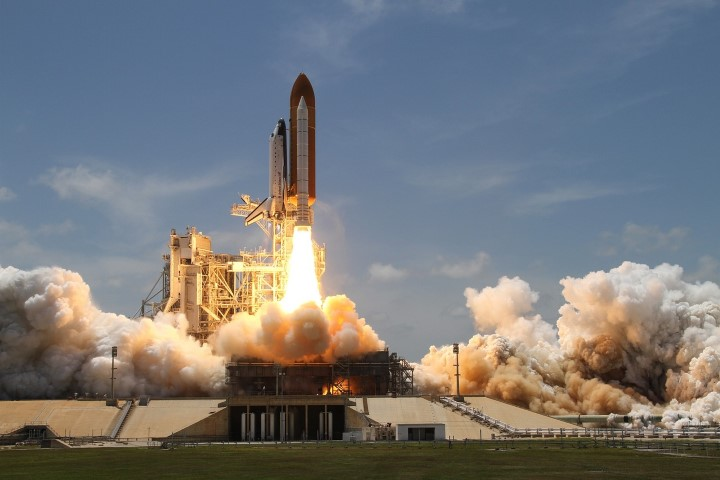

Bild von <a href="https://pixabay.com/de/users/wikiimages-1897/?utm_source=link-attribution&utm_medium=referral&utm_campaign=image&utm_content=67723">WikiImages</a> auf <a href="https://pixabay.com/de//?utm_source=link-attribution&utm_medium=referral&utm_campaign=image&utm_content=67723">Pixabay</a>

# 1 | Verbindung zu Google Drive herstellen
---

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

# 2 | Kursmaterial kopieren
---

Im Verzeichnis `/content/drive/MyDrive/ML_Intro` auf Google Drive werden die Kursunterlagen angelegt.

In [ ]:
!rm -rf /content/drive/MyDrive/ML_Intro
!git clone https://github.com/ralf-42/ML_Intro /content/drive/MyDrive/ML_Intro

# 3 | Notebook speichern
---


Datei | Kopie in Drive speichern

# Inhalt aus: `B020_pandas_basics.ipynb`
---

<p><font size="7" color='grey'> <b>
Machine Learning
</b></font> </br></p>

<p><font size="6" color='grey'> <b>
Pandas Basics - Daten zu Restaurant-Besuchen
</b></font> </br></p>


---

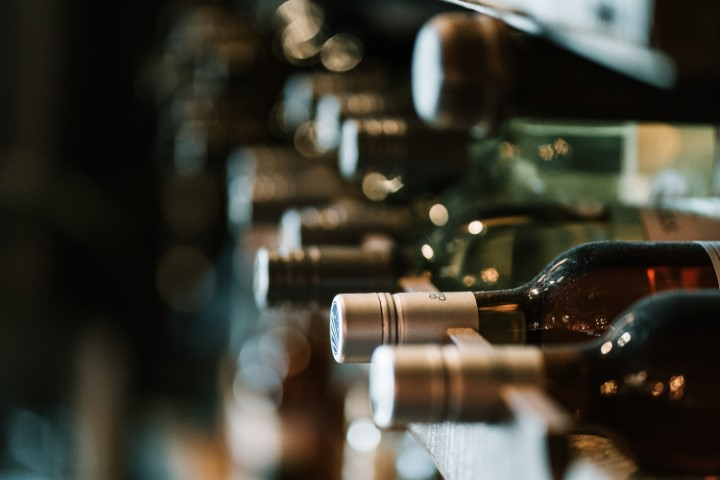

Foto von <a href="https://unsplash.com/de/@hermez777?utm_source=unsplash&utm_medium=referral&utm_content=creditCopyText">Hermes Rivera</a> auf <a href="https://unsplash.com/de/fotos/aK6WGqxyHFw?utm_source=unsplash&utm_medium=referral&utm_content=creditCopyText">Unsplash</a>
  

# Import Bibliotheken

In [ ]:
import pandas as pd
import plotly.express as px
import numpy as np

# Daten vorbereiten

In [ ]:
tips = px.data.tips()

data = tips.drop(["tip"], axis=1)
target = tips.tip

data.head(4)

# Information zu Daten abfragen


In [ ]:
data.describe().T

In [ ]:
data.columns

In [ ]:
data.dtypes

In [ ]:
data.shape

In [ ]:
duplicates = data["time"].duplicated(keep="first")

In [ ]:
data.ndim

In [ ]:
data.size

In [ ]:
data["total_bill"].mean()

In [ ]:
data.corr(numeric_only=True, method="pearson")
data.corr(numeric_only=True, method="spearman")

In [ ]:
data.corrwith(
    data["total_bill"], numeric_only=True
)  # method{‘pearson’, ‘kendall’, ‘spearman’} or callable

In [ ]:
data.count()

In [ ]:
data.cov(numeric_only=True)

In [ ]:
data.std(numeric_only=True)

# EDA - Exploratory Data Analysis

In [ ]:
!uv pip install -q --system ydata-profiling

In [ ]:
# Import
import numpy as np
import ydata_profiling
from ydata_profiling.utils.cache import cache_file

In [ ]:
# Bericht erstellen und als html speichern
profile_report = tips.profile_report(explorative=True, html={"style": {"full_width": True}})
profile_report.to_file("eda_report.html")
profile_report

# DataFrame - Indizierung

In [ ]:
# Spalte/Series
data["time"]

In [ ]:
# Zeile, Zeile von/bis
data.iloc[10]
data.iloc[10:15]

In [ ]:
# Teilbereiche: Zeile von/bis und Spalte von/bis
data.iloc[10:15, 2:4]

In [ ]:
# Teilbereiche alle Zeile, 1-2 Spalte
data.loc[:, "time"]
data.loc[:, ["time", "day"]]
data.loc[:, "time":"day"]

In [ ]:
# eine Zelle mit loc/iloc
data.iloc[10, 0]
data.loc[10, "day"]

# DataFrame aufbreiten

In [ ]:
data.isna().sum()  # Detect missing values

In [ ]:
data.fillna(0)  # Fill NA/NaN values using the specified method. Hier fehlende Werte werden durch 0 ersetzt

In [ ]:
data["total_bill"] = data["total_bill"].replace(10.27, 10.99)

# DataFrames copy, insert, delete, drop

In [ ]:
data_neu = data.copy()
data_neu.shape

In [ ]:
data.insert(4, "target", data.sex)

In [ ]:
data.pop("target")  # Return item and delete from frame.

In [ ]:
data.drop(["size"], axis=1)  # return frame without specified column  - not delete

In [ ]:
data.dropna()  # Remove missing values. axis{0 or ‘index’, 1 or ‘columns’}, default 0

# DataFrames iterieren

In [ ]:
# Iterate over (column name, Series) pairs.
for label, content in data.items():
    print(f"label: {label}")
    print(f"content: {content}", sep="\n")

In [ ]:
for row in data.itertuples():
    print(row)

# DataFrames logische Operatoren

In [ ]:
data.isin([6.2])  # Whether each element in the DataFrame is contained in values, return true/false

In [ ]:
data.total_bill == 6.2

In [ ]:
data.total_bill >= 5.0

# DataFrames arithmetische Operatoren

In [ ]:
data.total_bill.add(100)

In [ ]:
data.total_bill.sub(100)

In [ ]:
data["total_bill"].divide(100)

In [ ]:
import numpy as np

data.apply(np.sum, axis=0)

# Inhalt aus: `B030_gemini_colab.ipynb`
---

<p><font size="6";  color='grey'> <b>
Machine Learning
</b></font> </br></p>
<p><font size="5" color='grey'> <b>
Gemini
</b></font> </br></p>

---


# **1 | Gemini in Google Colab**
---



Google Colaboratory (oft kurz "Colab" genannt) ist eine hervorragende Umgebung, um Python zu lernen und zu programmieren. Es bietet eine kostenlose Python-Umgebung direkt im Browser, ohne dass eine Installation auf dem eigenen Computer erforderlich ist. Eine besonders nützliche Funktion ist die Integration von Gemini, einem leistungsstarken KI-Modell von Google. Gemini kann auf vielfältige Weise beim Programmieren in Python unterstützen. Es bietet sowohl technische Unterstützung beim Schreiben von Code als auch didaktische Erklärungen, die beim Verständnis komplexer Konzepte helfen.

**Zugriff auf Gemini in Google Colaboratory**

1. **Ein Colab-Notebook öffnen:** Auf [https://colab.research.google.com/](https://colab.research.google.com/) kann ein neues Notebook erstellt oder ein bestehendes geöffnet werden.
2. **Das Gemini-Panel öffnen:** Auf der linken Seite des Colab-Fensters befindet sich eine vertikale Leiste mit verschiedenen Symbolen. Dort auf das Symbol klicken, das wie ein **kleines, stilisiertes "G"** aussieht (möglicherweise mit "Gemini" oder "Assistent" beschriftet). Dadurch öffnet sich das Gemini-Panel auf der rechten Seite.

**Die beiden Modi von Gemini: Codezeile und Chat**

Gemini bietet zwei Hauptmöglichkeiten, um beim Programmieren zu unterstützen: direkt in einer Codezeile und über ein Chatfenster. Beide Modi haben ihre Vorteile und können je nach Aufgabe hilfreich sein. Es empfiehlt sich, beide Varianten auszuprobieren, um herauszufinden, welche Form der Interaktion in bestimmten Lernsituationen am hilfreichsten ist.



Ob und in welchem Umfang Gemini das Coding unterstützt, wird über die Einstellungen festgelegt.


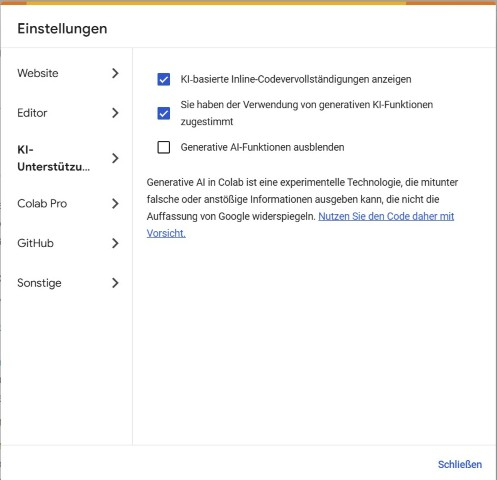


# **2 | Gemini in der Codezeile**
---



Dieser Modus ist besonders praktisch, wenn gerade Code geschrieben wird und direkt Unterstützung benötigt wird. Gemini integriert sich hier wie eine intelligente Autovervollständigung, die nicht nur die Syntax erkennt, sondern auch kontextabhängig relevante Vorschläge macht.

**Funktionsweise:**

1. **In einer Codezelle tippen:** Eine neue Codezelle im Colab-Notebook erstellen.
2. **Automatische Vervollständigung und Vorschläge nutzen:** Beim Tippen versucht Gemini, den Code zu vervollständigen oder mögliche nächste Schritte vorzuschlagen. Häufig werden ganze Codeblöcke oder Funktionsaufrufe angezeigt. Die Vorschläge passen sich dabei an den bisher geschriebenen Code an.
3. **Direkte Fragen als Kommentar formulieren:** Fragen können direkt in einer Codezeile gestellt werden, indem ein Kommentar mit einem `#` beginnt. Das ist besonders nützlich, um kontextbezogene Hilfe zu erhalten, ohne das Notebook verlassen zu müssen.

**Beispiele für die Nutzung in der Codezeile:**

- **Code-Vervollständigung:**

  ```python
  # Ich möchte eine Liste erstellen. Wie mache ich das?
  meine_liste = [
  ```

  Nach dem Drücken der Enter-Taste oder kurzem Warten schlägt Gemini möglicherweise vor, wie Elemente zur Liste hinzugefügt werden können.

- **Funktionsvorschläge:**

  ```python
  import math
  # Ich möchte die Quadratwurzel einer Zahl berechnen.
  math.sq
  ```

  Gemini wird wahrscheinlich `math.sqrt()` als mögliche Funktion vorschlagen.

- **Direkte Fragen im Kommentar:**

  ```python
  # Wie kann ich eine Schleife verwenden, um alle Elemente einer Liste auszugeben?
  meine_liste = ["Apfel", "Banane", "Kirsche"]
  # Gemini könnte hier einen Codevorschlag für eine for-Schleife machen.
  ```

**Vorteile für Einsteigerinnen und Einsteiger:**

- **Schnelles Erlernen von Syntax:** Es wird direkt sichtbar, wie Code korrekt geschrieben wird.
- **Entdecken neuer Funktionen:** Gemini kann Funktionen oder Module vorschlagen, die eventuell noch unbekannt sind.
- **Weniger Tippfehler:** Die automatische Vervollständigung hilft, Tippfehler zu vermeiden.
- **Sofortige Hilfestellung:** Einsteigerinnen und Einsteiger erhalten proaktive Unterstützung, ohne eine externe Dokumentation durchsuchen zu müssen.

**Wichtig:** Vorschläge sollten kritisch hinterfragt werden. Es empfiehlt sich, die Funktionsweise des vorgeschlagenen Codes zu verstehen und bei Bedarf Rückfragen zu stellen oder im Chat-Modus vertiefende Erklärungen einzuholen.



# **3 | Gemini als Chat**
---



Der Chat-Modus ermöglicht eine interaktivere und detailliertere Kommunikation mit Gemini. Es können Fragen gestellt, Code-Schnipsel eingefügt und Erklärungen eingeholt werden. Dieser Modus eignet sich besonders für konzeptuelle Fragen, detaillierte Analysen und das gemeinsame Lösen von Aufgabenstellungen.

**Funktionsweise:**

1. **Das Gemini-Panel öffnen:** Falls noch nicht geschehen, das Panel auf der rechten Seite öffnen.
2. **Frage oder Anweisung im Chatfenster eingeben:** Die Anfrage sollte klar und präzise formuliert sein. Kontextinformationen helfen Gemini, bessere Antworten zu liefern.
3. **Antwort von Gemini erhalten:** Gemini versucht, die Frage zu beantworten, Code-Beispiele zu liefern oder Konzepte zu erklären. Oft folgen auf die erste Antwort weiterführende Hinweise oder Nachfragen, die helfen, das Verständnis zu vertiefen.

**Beispiele für die Nutzung im Chat:**

- **Erklärung von Python-Konzepten:**

  - "Was ist der Unterschied zwischen einer Liste und einem Tupel in Python?"
  - (Gemini antwortet mit einer ausführlichen Erklärung und Beispielen.)

- **Code für eine bestimmte Aufgabe generieren:**

  - "Ein Python-Skript, das alle geraden Zahlen zwischen 1 und 10 ausgibt."
  - (Gemini liefert den entsprechenden Code.)

- **Fehlersuche (Debugging):**

  - "Fehlermeldung: `TypeError: unsupported operand type(s) for +: 'int' and 'str'`. Was bedeutet das?"
  - (Gemini erklärt den Fehler und gibt Lösungsvorschläge.)

- **Alternative Lösungen vorschlagen:**

  - "Gibt es eine einfachere Möglichkeit, die Summe einer Liste zu berechnen?"
  - (Gemini könnte die Verwendung von `sum()` vorschlagen.)

**Vorteile für Einsteigerinnen und Einsteiger:**

- **Direktes Fragen:** Gemini kann wie ein Tutor genutzt werden.
- **Verständliche Erklärungen:** Komplexe Konzepte werden in einfachen Worten dargestellt.
- **Hilfe bei Problemen:** Bei Herausforderungen in Programmieraufgaben kann Gemini unterstützen.
- **Interaktive Lernumgebung:** Die Konversation mit Gemini fühlt sich natürlich an und kann auf individuelle Bedürfnisse eingehen.

**Tipps für die effektive Nutzung von Gemini:**

- **Präzise Fragen stellen**
- **Kontext angeben:** Beispielsweise den relevanten Code mit angeben.
- **Experimentieren:** Unterschiedliche Fragetypen ausprobieren.
- **Antworten kritisch überprüfen**
- **Beide Modi nutzen:** Codezeile für schnelle Hilfe, Chat für tiefergehende Fragen.
- **Verständnis ist wichtiger als Kopieren:** Ziel ist das Lernen, nicht nur das Übernehmen von Code.
- **Nachfragen erlaubt:** Gemini kann auch auf Folgefragen eingehen oder vorherige Erklärungen anpassen.




# **4 | Anwendungsbeispiele**
---



Gemini kann auf unterschiedliche Weise eingesetzt werden. Die folgende Liste gibt eine Übersicht über typische Anwendungsfälle:

- **Codegenerierung:** Automatisches Erstellen von Code anhand einer textbasierten Beschreibung einer Aufgabe.
- **Codeergänzung:** Vorschläge für den nächsten Codeblock oder passende Befehle beim Tippen in der Codezelle.
- **Erklärung von Konzepten:** Begriffe wie Schleifen, Bedingungen, Datentypen oder Funktionen verständlich erklären lassen.
- **Debugging:** Hilfe bei Fehlermeldungen oder unerwartetem Verhalten des Codes, inklusive Vorschlägen zur Fehlerbehebung.
- **Codeoptimierung:** Vorschläge zur Verbesserung der Effizienz, Lesbarkeit oder Struktur eines bestehenden Codes.
- **Refactoring:** Hilfe beim Umstrukturieren von Code, z. B. durch Auslagerung in Funktionen oder bessere Benennung von Variablen.
- **Testgenerierung:** Erstellung einfacher Testfälle oder Unit-Tests für eine Funktion.
- **Lösungsvorschläge für Aufgaben:** Bearbeitung typischer Übungsaufgaben oder Programmierprobleme, z. B. aus Lehrbüchern oder Online-Kursen.
- **Modulauswahl:** Empfehlungen, welches Modul oder welche Bibliothek für eine bestimmte Aufgabe geeignet ist.
- **Begriffsdefinitionen:** Schnelle Erklärungen für Begriffe wie "Iterator", "Lambda-Funktion" oder "List Comprehension".
- **Integration mit externen APIs:** Hilfestellung beim Aufbau von Schnittstellen zu anderen Webdiensten oder Datenquellen.

Diese Anwendungsbeispiele zeigen, wie vielseitig Gemini in der Programmierpraxis unterstützen kann – sowohl beim Lernen als auch bei der täglichen Arbeit mit Python. Der Einsatz von Gemini spart Zeit, reduziert Frustration und fördert ein besseres Verständnis der Sprache und ihrer Konzepte.


# **5 | Kodieren**
---

LLMs sind Experten im Generieren von Code und können die Produktivität von Programmierern erheblich steigern.

<p><font color='black' size="5">
Kontext geben
</font></p>

`Gemini`

> Du bist Experte in der Erstellung von Python-Code für Aufgaben im Bereich `Generativer KI` und unterstützen mich bei der Code-Generierung. Der Code sollte gut strukturiert und möglichst einfach sein. Die wesentliche Code-Blocke werden kommentiert. Es wird dabei immer die neueste Version der benutzen Bibliotheken, wie z.B. sklearn v1.3+ oder neuer, verwendet. Die verwendeten Funktionen sollten nicht `deprecated` sein.







<p><font color='black' size="5">
Einfache Aufgabe
</font></p>

Nachdem der Kontext definiert wurde, kann man nun Code generieren. Der folgende Prompt generiert eine Python-Funktion zum Erstellen einer Fibonacci-Folge.

`Gemini`



> Schreibe Python-Code, um eine Fibonacci-Folge mit einer durch den Parameter l angegebenen Länge zurückzugeben




<p><font color='black' size="5">
Komplexere Aufgabe - Steuer:
</font></p>

[Berechnung](https://www.finanz-tools.de/einkommensteuer/berechnung-formeln/2025)

`Gemini`

> Schreibe eine Python-Funktion namens `einkommensteuer`, die diese Parameter akzeptiert.
+ zve: zu versteuerndes Einkommen p.a.
+ tarif: Grundtarif oder Splitting.
Unterscheide Fälle mit nach den gesetz­lich fest­gelegten Formeln.

> Die Funktion sollte eine Liste zurückgeben, die folgende Angaben enthält:
+ steuersatz: Steuersatz
+ steuer: Einkommensteuer p.a.
+ soli: Solidaritätszuschlag p.a.

<p><font color='black' size="5">
Komplexere Aufgabe: Neuronales Netz
</font></p>



`Gemini`

> **Augabe**: Erstellung eines neuronalen Netzwerks mit Keras zur Klassifikation der Iris-Arten   
**Ziel**: Entwickle und trainiere ein neuronales Netzwerk unter Verwendung der Keras-Bibliothek und des Iris-Datensatzes von sklearn, um die Arten der Iris-Blumen basierend auf ihren Merkmalen zu klassifizieren.   
**Daten**: Verwende den Iris-Datensatz, der über die sklearn.datasets verfügbar ist. Dieser Datensatz enthält 150 Instanzen von Iris-Blumen, unterteilt in drei Arten, sowie vier Merkmale: Sepallänge, Sepalbreite, Petallänge und Petalbreite.

# **6 | Revision**
---


Im nächsten Schritt wird mit dem LLM ein Dialog geführt, um Änderungen am ausgegebenen Code anzufordern und ein besseres Modell zu erstellen.



Es ist sinnvoll, sich ein Prompt-Template zu erstellen, dass bei vergleichbaren Aufgabenstellungen wieder verwendt werden kann.

`Gemini`



> **Template**: <br> Prüfe und optimiere den beigefügten Code. Wenn Du Kommentare zum Code hast, stelle sie vor den Code. Alle Hinweise zur Ausführung sollten dem Code folgen. Verwende Doc-Strings für eine Kurz-Dokumentation. Sortieren die erforderlichen Importe nach Bibliotheken und befolge die PEP-8-Formatierung. Wenn Informationen fehlen, frage nach. Mache Vorschläge, für mögliche Verbesserungen des generierten Codes.  <br>    
`Code`




<p><font color='black' size="5">
Ändern des Codes
</font></p>

Das Ergebnis kann durch das LLM verändert bzw. optimiwert werden. Die erfolgt über zusätzliche Eingabeaufforderung.

Gemini



> Bitte erstelle eine farbige Confusion-Matrix mit den Ergebnissen der Klassifizierung.



<p><font color='black' size="5">
Testen des Codes
</font></p>

Der generierte Code muss getestet werden. Da auch bei der Erstellung durch ein LLM das Ergebnis unvollständig, fehlerhaft oder nicht mehr aktuell sein kann.

Bei Verwendung von `Gemini` innerhalb von Google Colab kann dies direkt im Notebook erfolgen. Andere ChatBots bieten die Möglichkeit Code direkt auszuführen (z.B. `ChatGPT` Canvas oder `Claude` Artifacts). Ist dies nicht möglich muss der erstellte Code in die Entwicklunsgumgebung zur Ausführung kopiert werden.

Fehlermeldung sind dem LLM mitzuteilen. Das LLM wird mit einer Erläuterung der Fehlermeldung, Lösungsvorschlägen und ggf. einem korrigierten Code reagieren.

<p><font color='black' size="5">
Konsolidierung der Konversation in einem Prompt
</font></p>

Man kann die gesamte Konversation in einem einzigen Prompt zusammenfassen, insbesondere wenn man den Prompt zusammen mit dem Code speichern möchte oder eine `optimierte` Version eines Templates für kommende Aufgaben erstellt werden soll. Bei Bedarf bitte *Nachbesserung* des Prompts anfordern.

`Gemini`

> Bitte aus dem Chatverlauf eine konsolidierte ud optimierte Version des Prompts erstellen.



# **7 | Debugging**
---

LLMs können beim Debuggen von *eigenem* oder *fremdem* Code helfen.  

*Es kann das Template bzw. der Code von 2. verwendet werden.*

`Gemini`

> Ich versuche, den folgenden Code zu debuggen: <br>
... Code hier angeben... <br>
Ich erhalte jedoch die folgende Fehlermeldung:<br>
... Fehler hier hinzufügen, Stacktrace angeben...

**Hinweis**:

Bei Ausfügrung des fehlerhaften Code in Colab werden unterhalb der Fehlermeldung eone Schaltfläche angezeigt, die zum Debuggen verwendet werden kann. Nachfolgend kann der korrigierte Code übernommen werden.



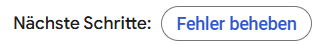

<p><font color='black' size="5">
Codeerklärung
</font></p>

LLMs sind gut darin, Code zu erklären.

`Gemini`

> Bitte erkläre mir den nachfolgende Code.<br>
... Code   ...

In [ ]:
#
# Codebeispiel
#
def funktion(text, verschiebung):
    v_text = ""
    for char in text:
        index = ord(char) + verschiebung
        v_text += chr(index)
    return v_text

text = input("Text: ")
verschiebung = int(input("Verschiebung (ganze Zahl): "))
funktion(text, verschiebung)

<p><font color='black' size="5">
Code optimieren
</font></p>

LLM können sehr gut eingesetzt werden, um Code zu verbessern. Sie können spezifische Verbesserungen nennen, die geünscht werden, wie z. B. das Entfernen nicht verwendeter oder redundanter Importe, das Einfügen von Kommentaren oder doc-strings, das Sortieren der Importe und die Einhaltung von PEP-8 für die Codeformatierung.

`Gemini`

> Bitte Verbesserungen für den nachfolgenden Code vorschlagen. Achte auf Modularisierung und die Einhaltung von PEP-8 für die Codeformatierung.  <br>
... Code ...



# **8 | Grenzen**
---

Während LLMs die Produktivität in der Softwareentwicklung deutlich steigern können, ist es ebenso wichtig, ihre Grenzen zu kennen, insbesondere bei der Codegenerierung. Die folgende Liste fasst mögliche Grenzen kurz und knapp zusammen.


**Analyse großer Datenmengen**
- LLMs haben kein intrinsisches Verständnis für neue Daten
- Speicher- und Verarbeitungsbeschränkungen durch begrenzte Kontextfenster
- Schwierigkeiten beim Umgang mit unstrukturierten Daten und unbekannter Datenqualität
- **Empfehlung**: Kombination von LLMs mit traditionellen Datenanalysetools und Vorverarbeitung

**Arbeiten an der Grenze des Verständnisses**
- Begrenzte Fähigkeit zur echten Innovation
- Kein tiefgehendes technisches Verständnis für komplexe Systeme
- Keine Fähigkeit zur Selbstverbesserung des eigenen Codes
- **Empfehlung**: Mensch-KI-Kollaboration und iterative Entwicklung

**Iterative Verbesserung**
- Keine Zustandspersistenz zwischen Interaktionen
- Schwierigkeiten bei der Bewertung von Code-Effizienz
- Eingeschränkte Fähigkeit zur Hyperparameter-Optimierung
- **Empfehlung**: Integration mit AutoML-Systemen und überwachte Iterationen

**Umgang mit Bibliotheks-Updates**
- Keine Echtzeit-Updates des Wissens
- Schwierigkeiten beim Verstehen von Breaking Changes
- Generierung möglicherweise veralteten Codes
- **Empfehlung**: Manuelle Codeprüfung und Integration von CI-Tools

**Neue Bibliotheken**
- Fehlendes Training mit neuen Bibliotheken
- Unkenntnis aktueller Best Practices
- Generische statt spezifischer Lösungen
- **Empfehlung**: Kombination mit aktueller Dokumentation und Expertenwissen

**Proprietäre Funktionsbibliotheken**
- Keine Kenntnis unternehmensinterner Bibliotheken
- Schwierigkeiten mit komplexen Abhängigkeiten
- Mangelndes Verständnis für Unternehmensstandards
- **Empfehlung**: Anpassung durch Training und Integration von Unternehmenswissen

**Monolithische Softwareprojekte**
- Überforderung durch Komplexität und Umfang
- Schwierigkeiten beim Verständnis von Abhängigkeiten
- Probleme mit Legacy-Code
- **Empfehlung**: Inkrementelle Änderungen und strenge Überprüfung durch Entwickler

LLMs haben trotz ihrer Stärken wichtige Einschränkungen, die durch geeignete Strategien und die Kombination mit menschlicher Expertise ausgeglichen werden müssen.

# Inhalt aus: `B040-use-cases.ipynb`
---

<p><font size="6" color='grey'> <b>
Machine Learning
</b></font> </br></p>
<p><font size="5" color='grey'> <b>
Use Cases
</b></font> </br></p>

---

# 0 | Intro
---

Der Kurs konzentriert sich auf **grundlegende Machine-Learning-Konzepte**, die an Anwendungsfällen veranschaulicht werden. Anhand derer kann man Daten analysieren, Modelle trainieren und bewerten und diese auf praktische Fragestellungen anwendet. So erhält man nicht nur theoretisches Wissen, sondern auch wertvolle Einblicke in die **praktische Anwendung** von Machine Learning.



<p><font color='darkblue' size="4">
💡 Tipp
</font></p>

Vorschlag zum Vorgehen:

* Anwendungsfall **passend** zum aktuellen Kontext (Klassifizierung, Regression, ...) auswählen
* Notebook-template kopieren
* Code-Zeilen für die Datenübernahme ins Notebook einfügen
* Schrittweise Modellentwicklung nach Phasenschema (Understand, Prepare, ...)

<p><font color='darkblue' size="4">
🛠️ Toolset
</font></p>

Bei der Lösung können folgende Tools bzw. Schritte helfen:

1. Anwenden des **Phasenschemas** - fokussiert auf den ersten/nächten Schritt
2. **Checkliste** zur Phase gibt konkrete Hinweise zu den ToDo's je Phase/Schritt
3. **Beispiel-Code** gibt konkrete Hinweise für eine mögliche Lösung
4. **Code-Snippets** enthalten Code-Vorschläge für konkrete Schritte
5. Der Chatbot **Gemini** biete Hilfe, um Code zu erläutern, erstellen, debuggen
6. **Trainer** fragen



<p><font color='darkblue' size="4">
📋 Übersicht Anwendungsfälle
</font></p>



| Nr. | Aufgabe            | Klassifizierung | Regression | Clusteranalyse | Anomalydetection | Assoziationsanalyse | Bildverarbeitung | Textverarbeitung | Zeitreihenanalyse |
| --- | ------------------ | :-------------: | :--------: | :------------: | :--------------: | :-----------------: | :--------------: | :--------------: | :---------------: |
| 1   | Titanic            |        ✓        |     -      |       -        |        -         |          -          |        -         |        -         |         -         |
| 2   | Miles per Gallon   |        -        |     ✓      |       -        |        -         |          -          |        -         |        -         |         -         |
| 3   | Diamonds           |        -        |     ✓      |       ✓        |        -         |          -          |        -         |        -         |         -         |
| 4   | Cancer             |        ✓        |     -      |       ✓        |        ✓         |          -          |        -         |        -         |         -         |
| 5   | Power Plant        |        -        |     ✓      |       -        |        -         |          -          |        -         |        -         |         -         |
| 6   | Location           |        -        |     -      |       ✓        |        -         |          -          |        -         |        -         |         -         |
| 7   | Network Intrusion  |        ✓        |     -      |       -        |        ✓         |          -          |        -         |        -         |         -         |
| 8   | Food               |        -        |     -      |       -        |        -         |          ✓          |        -         |        -         |         -         |
| 9   | Body Performance   |        ✓        |     -      |       ✓        |        -         |          -          |        -         |        -         |         -         |
| 10  | Fraud Detection    |        ✓        |     -      |       -        |        ✓         |          -          |        -         |        -         |         -         |
| 11  | Bäckerei           |        -        |     -      |       -        |        -         |          ✓          |        -         |        -         |         -         |
| 12  | Krankheitssymptome |        -        |     -      |       -        |        -         |          ✓          |        -         |        -         |         -         |
| 13  | Waldbrand          |        -        |     -      |       -        |        -         |          ✓          |        -         |        -         |         -         |
| 14  | MNIST              |        ✓        |     -      |       ✓        |        -         |          -          |        ✓         |        -         |         -         |
| 15  | SPAM               |        ✓        |     -      |       -        |        -         |          -          |        -         |        ✓         |         -         |
| 16  | Wetter Hobart      |        -        |     ✓      |       -        |        -         |          -          |        -         |        -         |         ✓         |
| 17  | Fashion-MNIST      |        ✓        |     -      |       ✓        |        -         |          -          |        ✓         |        -         |         -         |
| 18  | Social Dilemma     |        ✓        |     -      |       ✓        |        -         |          -          |        -         |        ✓         |         -         |
| 19  | Australian Beer    |        -        |     ✓      |       -        |        -         |          -          |        -         |        -         |         ✓         |
| 20  | Kreditwürdigkeit   |        ✓        |     -      |       ✓        |        ✓        |          -          |        -         |        -         |         -         |
| 21  | Traffic            |        -        |     ✓      |       -        |        -         |          -          |        -         |        -         |         ✓         |
| 22  | Maintenance        |        -        |     ✓      |       -        |        ✓         |          -          |        -         |        -         |         -         |
| 23  | Telco-Customer-Churn        |        ✓        |     -      |       ✓        |        ✓        |          -          |        -         |        -         |         -         |

**Klassifizierung (11 Aufgaben)**
- **Titanic** - Überlebenswahrscheinlichkeit vorhersagen
- **Cancer** - Gut-/bösartige Tumore klassifizieren
- **Network Intrusion** - Netzwerkangriffe erkennen
- **Body Performance** - Leistungsklassen zuordnen
- **Fraud Detection** - Betrugsversuche identifizieren
- **MNIST** - Handgeschriebene Ziffern erkennen
- **SPAM** - Spam-Nachrichten klassifizieren
- **Fashion-MNIST** - Kleidungsstücke kategorisieren
- **Social Dilemma** - Sentiment-Analyse von Tweets
- **Kreditwürdigkeit** - Kreditrisiko bewerten
- **Telo-Customer-Churn** - Churnrisiko bewerten

**Regression (7 Aufgaben)**
- **Miles per Gallon** - Kraftstoffverbrauch vorhersagen
- **Diamonds** - Diamantpreise schätzen
- **Power Plant** - Stromerzeugung prognostizieren
- **Wetter Hobart** - Temperatur vorhersagen
- **Australian Beer** - Bierproduktion prognostizieren
- **Traffic** - Verkehrsaufkommen vorhersagen
- **Maintenance** - Wartungsparameter vorhersagen

**Clusteranalyse (9 Aufgaben)**
- **Cancer** - Abnormale Zellstrukturen erkennen
- **Diamonds** - Diamanten nach Eigenschaften gruppieren
- **Location** - Geographische Standorte clustern
- **Body Performance** - Leistungsgruppen identifizieren
- **MNIST** - Ähnliche Ziffern gruppieren
- **Fashion-MNIST** - Ähnliche Kleidungsstücke clustern
- **Social Dilemma** - Nutzergruppen nach Sentiment clustern
- **Kreditwürdigkeit** - Kreditrisiko bewerten
- **Telo-Customer-Churn** - Churnrisiko bewerten

**Anomalydetection (8 Aufgaben)**
- **Cancer** - Abnormale Zellstrukturen erkennen
- **Network Intrusion** - Ungewöhnliche Netzwerkaktivitäten
- **Fraud Detection** - Betrügerische Transaktionen
- **Maintenance** - Abnormale Maschinenwerte
- **Kreditwürdigkeit** - Kreditrisiko bewerten
- **Telo-Customer-Churn** - Churnrisiko bewerten

**Assoziationsanalyse (4 Aufgaben)**
- **Food** - Warenkorbanalyse
- **Bäckerei** - Produktkombinationen
- **Krankheitssymptome** - Symptom-Zusammenhänge
- **Waldbrand** - Risikofaktoren-Kombinationen

**Bildverarbeitung (2 Aufgaben)**
- **MNIST** - Handgeschriebene Ziffern (28x28 Pixel)
- **Fashion-MNIST** - Kleidungsbilder (28x28 Pixel)

**Textverarbeitung (2 Aufgaben)**
- **SPAM** - SMS-Nachrichten analysieren
- **Social Dilemma** - Tweet-Sentiment analysieren

**Zeitreihenanalyse (3 Aufgaben)**
- **Wetter Hobart** - Temperaturverlauf über Zeit
- **Australian Beer** - Monatliche Produktionsdaten
- **Traffic** - Stündliches Verkehrsaufkommen

<p><font color='darkblue' size="4">
✏️ Hinweise zur Nutzung
</font></p>


+ **Mehrfachzuordnungen:** Viele Datensätze eignen sich für verschiedene Ansätze. Beispielsweise kann der Diamonds-Datensatz sowohl für Preisvorhersagen (Regression) als auch für das Gruppieren ähnlicher Diamanten (Clusteranalyse) verwendet werden.

+ **Datenvorverarbeitung:** Je nach Anwendungsbereich sind unterschiedliche Preprocessing-Schritte erforderlich (fehlende/unplausible Werte, Ausreisser, Normalisierung, Encoding kategorischer Variablen).

+ **Evaluationsmetriken:** Die Bewertung der Modelle erfolgt je nach Kategorie mit verschiedenen Metriken (Accuracy, RMSE, Silhouette Score, etc.).
+ **Weitere Empfehlungen:** siehe Abschnitte A bis C am Ende des Notebooks.

# 1 | Titanic
---

<p><font color='black' size="5">
📒 Anwendungsfall
</font></p>

Dies ist der legendäre Titanic ML-Wettbewerb – die beste erste Herausforderung, um in ML-Modellierung einzutauchen.

Die Aufgabe ist einfach: Verwenden Sie maschinelles Lernen, um ein Modell zu erstellen, das vorhersagt, welche Passagiere den Schiffbruch der Titanic überlebt haben.

[Titanic Org](https://www.encyclopedia-titanica.org/)

[DataSet](https://www.openml.org/search?type=data&status=active&id=41265)

[Info](https://www.kaggle.com/competitions/titanic/data)



**Datenfelder:**   
+ Age: Alter
+ Fare: Ticketpreis
+ Sex: Geschlecht (0 = männlich, 1 = weiblich)
+ sibsp: Der Datensatz definiert Familienbeziehungen auf diese Weise ... Geschwister = Bruder, Schwester, Stiefbruder, Stiefschwester Ehepartner = Ehemann, Ehefrau (Geliebte und Verlobte wurden ignoriert)
+ parch: Der Datensatz definiert Familienbeziehungen auf diese Weise ... Elternteil = Mutter, Vater Kind = Tochter, Sohn, Stieftochter, Stiefsohn. Einige Kinder reisten nur mit einem Kindermädchen, daher ist für sie Parch=0
+ Pclass: Passagierklasse, 1.- 3. Klasse
+ Embarked: Hafen der Einschiffung

In [ ]:
from pandas import read_csv
df = read_csv(
    "https://raw.githubusercontent.com/ralf-42/ML_Intro/main/02%20data/Titanic.csv",
    usecols=["pclass", "survived", "sex", "age", "sibsp", "parch"],
)

In [ ]:
data = df.copy()
target = data.pop("survived")

# 2 | Miles per Gallon
---

<p><font color='black' size="5">
📒 Anwendungsfall
</font></p>

Die Daten betreffen den Kraftstoffverbrauch im Stadtverkehr in Meilen pro Gallone, der anhand fünf kontinuierlichen Attributen vorhergesagt werden kann.



[DataSet](https://www.openml.org/search?type=data&status=active&id=42372)

[Info](https://archive.ics.uci.edu/dataset/9/auto+mpg)


In [ ]:
from pandas import read_csv
df = read_csv(
    "https://raw.githubusercontent.com/ralf-42/ML_Intro/main/02%20data/Auto-Mpg.csv",
    usecols=[
        "mpg",
        "cylinders",
        "displacement",
        "horsepower",
        "weight",
        "acceleration",
        "model year",
        "origin",
    ],
)

In [ ]:
data = df.copy()
target = data.pop("mpg")

# 3 | Diamonds
---

<p><font color='black' size="5">
📒 Anwendungsfall
</font></p>


Dieser klassische Datensatz enthält die Preise und andere Attribute von fast 54.000 Diamanten.



[DataSet](https://www.openml.org/search?type=data&status=active&id=42225)

[Info](https://www.kaggle.com/datasets/shivam2503/diamonds)


In [ ]:
from pandas import read_csv
df = read_csv(
    "https://raw.githubusercontent.com/ralf-42/ML_Intro/main/02%20data/diamonds.csv",
    usecols=[
        "carat",
        "cut",
        "color",
        "clarity",
        "depth",
        "table",
        "price",
    ],
)

In [ ]:
data = df.copy()
target = data.pop("price")

# 4 | Cancer
---

<p><font color='black' size="5">
📒 Anwendungsfall
</font></p>




**Beschreibung:**   
Diese Arbeit entstand aus dem Wunsch, Gewebeproben ausschließlich auf der Grundlage einer Feinnadelpunktion (FNA) genau zu diagnostizieren. In Zusammenarbeit mit Prof. Mangasarian und zwei seiner Doktoranden, Rudy Setiono und Kristin Bennett , wurde mithilfe der Multisurface-Methode (MSM) zur Mustertrennung dieser neun Merkmale ein Klassifikator erstellt, der 97 % der neuen Fälle erfolgreich diagnostizierte. Der resultierende Datensatz ist als Wisconsin Breast Cancer Data bekannt.


Die Arbeit an der Bildanalyse begann 1990 mit der Aufnahme von Nick Street in das Forschungsteam. Ziel war es, die Probe anhand eines digitalen Bildes eines kleinen Abschnitts des FNA-Objektträgers zu diagnostizieren.

**Diagnoseablauf:**

Es wird aus dem Gewebe eine FNA entnommen. Dieses Material wird dann auf einen Objektträger montiert und gefärbt, um die Zellkerne hervorzuheben. Ein Teil des Objektträgers, in dem die Zellen gut differenziert sind, wird dann mit einer Digitalkamera und einem Framegrabber-Board gescannt.
Anschließend isoliert der Anwender die einzelnen Zellkerne . Mit einem Mauszeiger zeichnet der Benutzer die ungefähre Grenze jedes Kerns. Mithilfe eines Computer-Vision-Ansatzes, konvergieren diese Annäherungen dann an die genauen nuklearen Grenzen. Sobald alle (oder die meisten) Kerne auf diese Weise isoliert wurden, berechnet das Programm Werte für jedes der zehn Merkmale jedes Kerns und misst Größe, Form und Textur. Der Mittelwert, der Standardfehler und die Extremwerte dieser Merkmale werden berechnet, was zu insgesamt 30 Kernmerkmalen für jede Probe führt.

[DataSet](https://archive.ics.uci.edu/dataset/15/breast+cancer+wisconsin+original)

[Info](https://pages.cs.wisc.edu/~olvi/uwmp/cancer.html)

**Wertebereich: 1 – 10**      
+ 1 = eher unauffällig / typisch gutartig        

+ 10 = stark auffällig / typisch bösartig



**Features:**


+ Dicke: 1 - 10
+ Einheitlichkeit der Zellgröße: 1 - 10
+ Gleichmäßigkeit der Zellform: 1 - 10
+ Randhaftung: 1 - 10
+ Größe einzelner Epithelzellen: 1 - 10
+ Nackte Kerne: 1 - 10
+ Blandes Chromatin: 1 - 10
+ Normale Nukleolen: 1 - 10
+ Mitosen: 1 - 10

**Klassen:**

+ Klasse: (2 für gutartig, 4 für bösartig)

**Kurzerläuterung:**

| **Merkmal**                           | **Erläuterung (einfach und verständlich)**                                                                            |
| ------------------------------------- | --------------------------------------------------------------------------------------------------------------------- |
| **Dicke** *(Clump Thickness)*         | Wie dick oder dicht gepackt die Zellverbände sind – dicker = potenziell auffälliger                                   |
| **Einheitlichkeit der Zellgröße**     | Wie ähnlich oder unterschiedlich die Zellgrößen sind – starke Unterschiede können auf Bösartigkeit hinweisen          |
| **Gleichmäßigkeit der Zellform**      | Wie regelmäßig die Zellformen sind – unregelmäßige Formen sind oft verdächtig                                         |
| **Randhaftung** *(Marginal Adhesion)* | Wie gut haften die Zellen aneinander – geringe Haftung kann auf bösartige Zellen hindeuten                            |
| **Größe einzelner Epithelzellen**     | Durchschnittliche Größe bestimmter Zellen – ungewöhnlich große Zellen können ein Risikozeichen sein                   |
| **Nackte Kerne** *(Bare Nuclei)*      | Zellkerne, die außerhalb von Zellen sichtbar sind – in größerer Zahl ein typisches Merkmal bösartiger Tumoren         |
| **Blandes Chromatin**                 | Wie gleichmäßig die DNA-Struktur im Zellkern aussieht – „bland“ heißt einheitlich, Abweichungen können auffällig sein |
| **Normale Nukleolen**                 | Nukleolen = Zellkernbestandteile – viele oder große Nukleolen sind oft in bösartigen Zellen zu finden                 |
| **Mitosen**                           | Zellteilungen – viele Mitosen deuten auf schnelles Zellwachstum hin, was ein Warnzeichen sein kann                    |


In [ ]:
from pandas import read_csv
df = read_csv('https://raw.githubusercontent.com/ralf-42/ML_Intro/main/02%20data/breast_cancer_wisconsin.csv')

In [ ]:
data = df.copy()
target = data.pop("Class")

# 5 | Power Plant
---

<p><font color='black' size="5">
📒 Anwendungsfall
</font></p>




Der Datensatz enthält 9568 Datenpunkte, die von einem Gas- und Dampfturbinenkraftwerk über einen Zeitraum von 6 Jahren (2006-2011) gesammelt wurden, als das Kraftwerk unter Volllast in Betrieb genommen wurde. Die Funktionen bestehen aus den stündlichen durchschnittlichen Umgebungsvariablen
+ Temperatur (T),
+ Umgebungsdruck (AP),
+ Relative Luftfeuchtigkeit (RH)
+ und Abgasvakuum (V),

um die stündliche Netto-Stromerzeugung (EP) der Anlage vorherzusagen.


Ein GuD-Kraftwerk (GuD-Kraftwerk) setzt sich aus Gasturbinen (GT), Dampfturbinen (ST) und Abhitzedampferzeugern zusammen. Bei einem GuD-Kraftwerk wird der Strom durch Gas- und Dampfturbinen erzeugt, die in einem Kreislauf kombiniert werden, und von einer Turbine auf eine andere übertragen. Während das Vakuum von der Dampfturbine beeinflusst wird und sich auf sie auswirkt, beeinflussen die anderen drei Umgebungsvariablen die GT-Leistung.

Der Hochdruckdampf in einem GuD-Kraftwerk wird im sogenannten Abhitzedampferzeuger (AHE) erzeugt – einem zentralen Bauteil, das die Abwärme der Gasturbine nutzt, um Wasser in Dampf umzuwandeln.

Nach der Expansion des Dampfes in der Dampfturbine muss dieser wieder kondensieren, um erneut im Kreislauf genutzt werden zu können. Das passiert im sogenannten Kondensator, einem Wärmeübertrager, in dem der Dampf durch Kühlwasser (z. B. Fluss- oder Meerwasser) abgekühlt wird.

Beim Kondensieren entsteht ein Unterdruck (Vakuum), weil Wasserdampf beim Übergang in den flüssigen Zustand viel Volumen verliert – und das senkt den Druck im Kondensator erheblich, typischerweise auf etwa 0,05 bar oder sogar weniger (je nach Kühlwassertemperatur).

Das Vakuum erhöht die Druckdifferenz über der Dampfturbine, also:

`Druck am Einlass (Hochdruckdampf)−Druck am Auslass (Vakuum)`


Je größer dieser Unterschied ist, desto mehr Energie kann der Dampf beim Expandieren in der Turbine abgeben.

Dadurch:

+ steigt die mechanische Leistung der Dampfturbine,

+ wird mehr Strom im Generator erzeugt,

+ und der Wirkungsgrad des gesamten GuD-Kraftwerks verbessert sich.

[DataSet](http://archive.ics.uci.edu/dataset/294/combined+cycle+power+plant)    
[Info](http://archive.ics.uci.edu/dataset/294/combined+cycle+power+plant)

In [ ]:
from pandas import read_csv
df = read_csv(
    "https://raw.githubusercontent.com/ralf-42/ML_Intro/main/02%20data/CCPP.csv"
)

In [ ]:
data = df.copy()
target = data.pop("PE")

# 6 | Location
---


<p><font color='black' size="5">
📒 Anwendungsfall
</font></p>

Geographiedaten mit Längen- und Breitenangeben für eine Clusteranalyse.



In [ ]:
from pandas import read_csv
filename = "https://raw.githubusercontent.com/ralf-42/ML_Intro/main/02%20data/location_data.csv"
df = read_csv(filename, encoding="ISO-8859-1")

In [ ]:
data = df[df.region == "California"]
data.reset_index(inplace=True)

In [ ]:
data = data[["Lat", "Long"]]

# 7 | Network Intrusion
---

<p><font color='black' size="5">
📒 Anwendungsfall
</font></p>

Dies ist der Datensatz, der für den Third International Knowledge Discovery and Data Mining Tools Competition verwendet wurde. Die Wettbewerbsaufgabe bestand darin, einen Netzwerk-Intrusion-Detektor zu bauen, ein Vorhersagemodell, das in der Lage ist, zwischen schlechten Verbindungen, sogenannten Intrusionen oder Angriffen, und guten normalen Verbindungen zu unterscheiden. Diese Datenbank enthält einen zu prüfenden Standarddatensatz, der eine Vielzahl von Eindringversuchen umfasst, die in einer militärischen Netzwerkumgebung simuliert wurden.

Der ursprüngliche KDD Cup 1999-Datensatz aus dem  UCI-Repositorium für maschinelles Lernen  enthält 41 Attribute (34 kontinuierlich und 7 kategorial), sie werden jedoch auf 3 Attribute (Dauer, src_bytes, dst_bytes) reduziert.

Da die kontinuierlichen Attributwerte um '0' herum konzentriert sind, haben wir jeden Wert durch y = log(x + 0,1) in einen Wert weit von '0' transformiert.

Aus KDD Cup 1999-Datensatz werden ca. 500k „http“-Dienstdaten verwendet.

Der KDD Cup ist der jährliche Data-Mining- und Knowledge-Discovery-Wettbewerb, der von der ACM Special Interest Group on Knowledge Discovery and Data Mining, der führenden Berufsorganisation von Data-Minern, organisiert wird.


[DataSet](https://www.openml.org/search?type=data&status=active&id=1113)

[Info](http://odds.cs.stonybrook.edu/http-kddcup99-dataset/)


[UCI](https://archive.ics.uci.edu/ml/datasets/kdd+cup+1999+data)

[KDD](https://kdd.org/kdd-cup)



**Datensatz:**

| feature name  | description                                      | type        |
|------------|--------------------------------------------------|-------------|
| duration   | length (number of seconds) of the connection     | continuous  |
| src_bytes  | number of data bytes from source to destination  | continuous  |
| dst_bytes  | number of data bytes from destination to source  | continuous  |

<br>
<br>


In [ ]:
from pandas import read_csv
df = read_csv(
    "https://raw.githubusercontent.com/ralf-42/ML_Intro/main/02%20data/kddcup1999_xs.csv"
)

In [ ]:
data = df.copy()
target = data.pop("Intrusion")

# 8 | Food
---

<p><font color='black' size="5">
📒 Anwendungsfall
</font></p>

Daten für eine Warenkorbanalyse.

In [ ]:
from pandas import read_csv
data = read_csv(
    "https://raw.githubusercontent.com/ralf-42/ML_Intro/main/02%20data/Basket_01_Format_1.csv",
    header=None,
)

# 9 | Body Perrformance
---

<p><font color='black' size="5">
📒 Anwendungsfall
</font></p>


Daten, die von der National Sports Promotion Foundation zum Gedenken an die Olympischen Spiele in Seoul verwaltet werden. Die Daten beinhatlten den Leistungsgrad, Altersgruppe, Größe, Gewicht, Sit-up, BMI und Weitsprung an Ort und Stelle, etc.  


[DataSet](https://www.kaggle.com/datasets/kukuroo3/body-performance-data)   
[Info](https://www.kaggle.com/datasets/kukuroo3/body-performance-data)   
[Quelle](https://www.bigdata-culture.kr/bigdata/user/data_market/detail.do?id=ace0aea7-5eee-48b9-b616-637365d665c1)



1. **Grip Force**: Bei dieser Übung wird die Kraft gemessen, die eine Person mit ihrer Hand ausüben kann, in der Regel mit einem Gerät namens Dynamometer. Die Teilnehmer drücken das Gerät so fest wie möglich zusammen. Die gemessene Kraft wird in Kilogramm oder Newton angegeben. **Negative Werte** sind hier nicht möglich, da die Kraftmessung immer einen positiven Wert oder null ergibt.

2. **Sit and Bend Forward_cm (Sitzen und nach vorne beugen in cm)**: Diese Übung misst die Flexibilität. Die Teilnehmer sitzen auf dem Boden mit gestreckten Beinen und beugen sich vorwärts, um so weit wie möglich mit den Händen voranzukommen. Die Distanz, die sie erreichen können, wird gemessen. **Negative Werte** könnten theoretisch auftreten, wenn die Startposition als Nullpunkt definiert ist und jemand nicht über diesen Punkt hinaus kommt. Allerdings ist das ungewöhnlich und hängt von der spezifischen Messmethode ab.

3. **Sit-ups Counts (Anzahl der Sit-ups)**: Diese Übung misst die Bauchmuskelkraft und Ausdauer. Die Teilnehmer führen so viele Sit-ups wie möglich in einer festgelegten Zeit durch. Die Ergebnisse werden als Anzahl der vollständig ausgeführten Sit-ups gezählt. **Negative Werte** sind hier nicht möglich, da es sich um eine Zählung handelt und diese bei null beginnt.

4. **Broad Jump_cm (Weitsprung in cm)**: Bei dieser Übung wird die explosive Beinkraft gemessen. Die Teilnehmer springen aus dem Stand so weit wie möglich nach vorne. Die Sprungdistanz wird in Zentimetern oder Metern gemessen. Auch hier sind **negative Werte** nicht möglich, da die Sprungweite immer einen positiven Wert oder null ergibt.

Negative Werte sind  generell unüblich und nur bei der "Sit and Bend Forward"-Messung denkbar, abhängig von der gewählten Messmethode und Startposition. In den meisten Fällen sind die Messwerte jedoch positiv oder null.

In [ ]:
from pandas import read_csv
df = read_csv(
    "https://raw.githubusercontent.com/ralf-42/ML_Intro/main/02%20data/BodyPerformance.csv"
)

In [ ]:
data = df[(df["class"] == "A") | (df["class"] == "D")]
target = data.pop("class")

# 10 | Fraud Detection
---


<p><font color='black' size="5">
📒 Anwendungsfall
</font></p>

Der Datensatz enthält fiktive Kreditkartentransaktionen.
Jeder Datensatz stellt Transaktionen dar, 100 Betrugsfälle bei 5.000 Transaktionen haben. Der Datensatz ist sehr unausgewogen, die positive Klasse (Betrug) macht 2% aller Transaktionen aus.

Der Datensatz enthält nur numerische Eingabevariablen, die das Ergebnis einer PCA-Transformation sind. Die Zielgröße nimmt im Betrugsfall den Wert 1 und andernfalls den Wert 0 an.

Angesichts des Klassenungleichgewichtsverhältnisses empfiehlt sich, die Genauigkeit anhand der Fläche unter der Präzisions-Recall-Kurve (AUPRC) zu messen. Die Genauigkeit der Konfusionsmatrix ist für eine unausgeglichene Klassifikation nicht aussagekräftig.   

<br>


In [ ]:
# Install
!uv pip install --system -q pyod
from pyod.utils.data import generate_data

In [ ]:
contamination = 0.02  # percentage of outliers
n_train = 5000  # number of training points
n_test = 0  # number of testing points
n_features = 5

data, target = generate_data(
    n_train=n_train,
    n_test=n_test,
    n_features=n_features,
    train_only=True,
    contamination=contamination,
    random_state=42,
)

In [ ]:
from pandas import DataFrame
data = DataFrame(data)
data.columns = ["Feature 1", "Feature 2", "Feature 3", "Feature 4", "Feature 5"]
target = DataFrame(target).astype(int)

# 11 | Bäckerei
---

<p><font color='black' size="5">
📒 Anwendungsfall
</font></p>

Der Datensatz gehört „The Bread Basket“, einer Bäckerei in Edinburgh. Der Datensatz hat 20507 Einträge, über 9000 Transaktionen und 4 Spalten (**Format 2**). Der Datensatz enthält Transaktionen von Kunden, die verschiedene Artikel bei dieser Bäckerei online bestellt haben.

[DataSet](https://www.openml.org/search?type=data&status=any&id=43422)

[Info](https://www.kaggle.com/datasets/mittalvasu95/the-bread-basket)


In [ ]:
from pandas import read_csv
df = read_csv(
    "https://raw.githubusercontent.com/ralf-42/ML_Intro/main/02%20data/Bread_Basket_Format_2.csv"
)

In [ ]:
data = df[["Transaction", "Item"]]

# 12 | Krankheitssymptome
---

<p><font color='black' size="5">
 📒Anwendungsfall
</font></p>

In diesem Anwendungsfall wird der Apriori-Algorithmus eingesetzt, um häufig auftretende Kombinationen von Symptomen in Patientenbesuchen zu identifizieren. Der Datensatz besteht aus einer Liste von Patientenbesuchen, wobei jede innere Liste die während eines Besuchs gemeldeten Symptome enthält.

Das Ziel ist es, Assoziationsregeln zu generieren, die zeigen, welche Symptomkombinationen häufig zusammen bei einem Patienten vorkommen. Beispielsweise könnte der Algorithmus feststellen, dass Patienten, die sowohl 'Fieber' als auch 'Husten' melden, mit hoher Wahrscheinlichkeit auch 'Müdigkeit' aufweisen.

Diese Analyse kann dazu beitragen, typische Symptommuster zu erkennen, potenzielle Zusammenhänge zwischen Symptomen aufzudecken und als Grundlage für weitere Analysen oder die Entwicklung von Diagnosemodellen zu dienen. Es ist wichtig zu beachten, dass der Algorithmus lediglich Assoziationen findet und keine Kausalität belegt.

In [ ]:
# Beispiel-Daten, die Patientenbesuche und gemeldete Symptome darstellt
# Jede innere Liste repräsentiert einen Patientenbesuch und die während dieses Besuchs gemeldeten Symptome
data = [
    ['Fieber', 'Husten', 'Halsschmerzen', 'Müdigkeit'],
    ['Fieber', 'Husten', 'Schnupfen', 'Müdigkeit'],
    ['Halsschmerzen', 'Kopfschmerzen', 'Müdigkeit'],
    ['Fieber', 'Husten', 'Halsschmerzen', 'Müdigkeit', 'Schnupfen'],
    ['Fieber', 'Kopfschmerzen', 'Müdigkeit'],
    ['Husten', 'Halsschmerzen', 'Schnupfen'],
    ['Fieber', 'Husten', 'Müdigkeit'],
    ['Halsschmerzen', 'Kopfschmerzen', 'Schnupfen', 'Müdigkeit'],
    ['Fieber', 'Halsschmerzen', 'Müdigkeit'],
    ['Husten', 'Schnupfen', 'Müdigkeit'],
    ['Fieber', 'Husten', 'Halsschmerzen', 'Müdigkeit'],
    ['Kopfschmerzen', 'Schnupfen', 'Müdigkeit'],
    ['Fieber', 'Husten', 'Schnupfen'],
    ['Halsschmerzen', 'Kopfschmerzen', 'Müdigkeit'],
    ['Fieber', 'Husten', 'Halsschmerzen', 'Müdigkeit']
]

# 13 | Waldbrand

---



<p><font color='black' size="5">
📒Anwendungsfall
</font></p>

In diesem Anwendungsfall wird der Apriori-Algorithmus eingesetzt, um häufig auftretende Kombinationen von Umweltbedingungen zu identifizieren, die mit dem Risiko von Waldbränden zusammenhängen. Der Datensatz enthält beobachtete Umweltbedingungen (z.B. Temperatur, Luftfeuchtigkeit, Wind, Vegetationszustand) an verschiedenen Tagen oder Zeiträumen, zusammen mit der Information, ob in diesem Zeitraum ein Waldbrand stattgefunden hat.

Das Ziel ist es, Assoziationsregeln zu generieren, die zeigen, welche Kombinationen von Umweltbedingungen häufig zusammen auftreten und wie stark sie mit dem Risiko eines Waldbrandes verbunden sind. Beispielsweise könnte der Algorithmus feststellen, dass die Kombination aus 'Hoher Temperatur', 'Niedriger Luftfeuchtigkeit', 'Starkem Wind' und 'Trockener Vegetation' besonders häufig an Tagen mit Waldbränden auftritt.

Diese Analyse kann dazu beitragen, typische Risikokombinationen für Waldbrände zu erkennen, potenzielle Frühwarnsignale zu identifizieren und als Grundlage für die Entwicklung von Risikobewertungsmodellen oder Präventionsstrategien zu dienen.

In [ ]:
# Beispiel-Daten, die Umweltbedingungen an verschiedenen Tagen/Perioden darstellen
# Jede innere Liste repräsentiert einen Tag/Zeitraum und die beobachteten Bedingungen
# Hinweis: Dies ist ein hypothetischer Datensatz zur Illustration.
data = [
    ['HoheTemperatur', 'NiedrigeLuftfeuchtigkeit', 'StarkerWind', 'TrockeneVegetation', 'Waldbrand'],
    ['HoheTemperatur', 'NiedrigeLuftfeuchtigkeit', 'ModeraterWind', 'TrockeneVegetation', 'KeinWaldbrand'],
    ['MittlereTemperatur', 'MittlereLuftfeuchtigkeit', 'FeuchteVegetation', 'KeinWaldbrand'],
    ['HoheTemperatur', 'NiedrigeLuftfeuchtigkeit', 'StarkerWind', 'TrockeneVegetation', 'Waldbrand'],
    ['HoheTemperatur', 'NiedrigeLuftfeuchtigkeit', 'ModeraterWind', 'TrockeneVegetation', 'KeinWaldbrand'],
    ['MittlereTemperatur', 'NiedrigeLuftfeuchtigkeit', 'StarkerWind', 'TrockeneVegetation', 'KeinWaldbrand'],
    ['HoheTemperatur', 'NiedrigeLuftfeuchtigkeit', 'StarkerWind', 'TrockeneVegetation', 'Waldbrand'],
    ['MittlereTemperatur', 'MittlereLuftfeuchtigkeit', 'ModeraterWind', 'FeuchteVegetation', 'KeinWaldbrand'],
    ['HoheTemperatur', 'NiedrigeLuftfeuchtigkeit', 'StarkerWind', 'TrockeneVegetation', 'Waldbrand'],
    ['HoheTemperatur', 'NiedrigeLuftfeuchtigkeit', 'ModeraterWind', 'TrockeneVegetation', 'KeinWaldbrand'],
    ['HoheTemperatur', 'NiedrigeLuftfeuchtigkeit', 'StarkerWind', 'TrockeneVegetation', 'Waldbrand'],
    ['MittlereTemperatur', 'NiedrigeLuftfeuchtigkeit', 'StarkerWind', 'TrockeneVegetation', 'KeinWaldbrand'],
    ['HoheTemperatur', 'NiedrigeLuftfeuchtigkeit', 'StarkerWind', 'TrockeneVegetation', 'Waldbrand'],
    ['MittlereTemperatur', 'MittlereLuftfeuchtigkeit', 'ModeraterWind', 'FeuchteVegetation', 'KeinWaldbrand'],
    ['HoheTemperatur', 'NiedrigeLuftfeuchtigkeit', 'StarkerWind', 'TrockeneVegetation', 'Waldbrand']
]

# 14 | MNIST
---

<p><font color='black' size="5">
📒 Anwendungsfall
</font></p>





Die MNIST-Datenbank ( Modified National Institute of Standards and Technology database ) ist eine große Datenbank mit handgeschriebenen Ziffern, die üblicherweise zum Trainieren verschiedener Bildverarbeitungssysteme verwendet wird.

Die MNIST-Datenbank mit handgeschriebenen Ziffern hat einen Trainingssatz von 60.000 Beispielen und einen Testsatz von 10.000 Beispielen mit jeweils  28x28 Pixel.







In [ ]:
import keras
(data_train, target_train), (data_test, target_test) = keras.datasets.mnist.load_data()

# 15 | SPAM
---


<p><font color='black' size="5">
📒 Anwendungsfall
</font></p>




Diese DataSet wurde aus Recherchequellen im Internet zusammengestellt: -> Eine Sammlung von 425 SMS-Spam-Nachrichten wurde manuell von der Grumbletext-Website extrahiert. Dies ist ein britisches Forum, in dem Mobiltelefonnutzer öffentliche Behauptungen über SMS-Spam-Nachrichten aufstellen, die meisten von ihnen, ohne die empfangene Spam-Nachricht selbst zu melden. Die Identifizierung des Textes von Spam-Nachrichten in den Ansprüchen ist eine sehr schwierige und zeitaufwändige Aufgabe und erforderte das sorgfältige Scannen von Hunderten von Webseiten.

Das Ziel ist es, ein Vorhersagemodell zu erstellen, das bestimmt, ob eine Textnachricht Spam oder Ham ist.


[Info](https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset)

[DataSet](https://archive-beta.ics.uci.edu/dataset/228/sms+spam+collection)






In [ ]:
from pandas import read_csv
df = read_csv(
    "https://raw.githubusercontent.com/ralf-42/ML_Intro/main/02%20data/SMSSpamCollection",
    sep="\t",
    header=None,
    names=["class", "msg"],
)

In [ ]:
data = df["msg"].copy()
target = df["class"].replace(["ham", "spam"], [0, 1]).copy()

# 16 | Wetter Hobart
---

<p><font color='black' size="5">
📒 Anwendungsfall
</font></p>




Dieser Datensatz enthält ungefähr 10 Jahre Wetterbeobachtungen von Hobart in Australien.

Die `Mittlere Temperatur` ist die vorherzusagende Zielvariable.
Prognostizieren die `Mittlere Temperatur`, indem Sie das Modelle mit der Zielvariablen trainieren.


[Info](https://www.kaggle.com/datasets/jsphyg/weather-dataset-rattle-package)

[DataSet](https://www.kaggle.com/datasets/jsphyg/weather-dataset-rattle-package)





In [ ]:
from pandas import read_csv
data = read_csv(
    "https://raw.githubusercontent.com/ralf-42/ML_Intro/main/02%20data/weather_hobart.csv"
)

# 17 | Fashion-MNIST
---


<p><font color='black' size="5">
  📒Anwendungsfall
</font></p>





Fashion-MNIST ist ein Datensatz von Zalandos Artikelbildern – bestehend aus einem Trainingsset mit 60.000 Beispielen und einem Testset mit 10.000 Beispielen. Jedes Beispiel ist ein 28x28-Graustufenbild, das einem Etikett aus 10 Klassen zugeordnet ist. Zalando beabsichtigt, dass Fashion-MNIST als direkter Drop-in-Ersatz für den ursprünglichen MNIST-Datensatz für das Benchmarking von Algorithmen für maschinelles Lernen dient. Es teilt die gleiche Bildgröße und Struktur der Trainings- und Testaufteilungen.

+ 0 T-shirt/top
+ 1 Trouser
+ 2 Pullover
+ 3 Dress
+ 4 Coat
+ 5 Sandal
+ 6 Shirt
+ 7 Sneaker
+ 8 Bag
+ 9 Ankle boot


[Info](https://www.kaggle.com/datasets/zalando-research/fashionmnist)

In [ ]:
import keras
(data_train, target_train), (data_test, target_test) = (
    keras.datasets.fashion_mnist.load_data()
)

# 18 | Social Dilemma
---


<p><font color='black' size="5">
📒 Anwendungsfall
</font></p>





„The Social Dilemma“, ein Dokumentarfilm-Drama-Hybrid, untersucht die gefährlichen menschlichen Auswirkungen sozialer Netzwerke. Erstveröffentlichung: Januar 2020 Regie: Jeff Orlowski Produzentin: Larissa Rhodes Musikalische Leitung: Mark A. Crawford Drehbuch: Jeff Orlowski, Vickie Curtis, Davis Coombe.

Dieser Datensatz zeigt Ihnen die Twitter-Antworten mit dem Hashtag TheSocialDilemma, nachdem Sie sich die aufschlussreiche Dokumentation angesehen haben „The Social Dilemma“ wurde am 9. September 2020 auf einer OTT-Plattform (Netflix) veröffentlicht. Der Datensatz wurde mit TwitterAPI extrahiert und besteht aus fast 10.526 Tweets von Twitter-Nutzern auf der ganzen Welt!



[Info](https://www.openml.org/search?type=data&status=active&id=43532)

[DataSet](https://www.openml.org/search?type=data&status=active&id=43532)






In [ ]:
from pandas import read_csv
df = read_csv('https://raw.githubusercontent.com/ralf-42/ML_Intro/main/02%20data/sentiment.csv')

In [ ]:
data = df.copy()
target = data.pop("Sentiment")

# 19 | Australian Beer
---


<p><font color='black' size="5">
📒Anwendungsfall
</font></p>





Monatliche australische Bierproduktion 1956 - 1995. Es soll eine monatliche Prognose auf Basis der Istdaten erfolgen.



[Info](https://www.kaggle.com/datasets/sergiomora823/monthly-beer-production)

[DataSet](https://www.kaggle.com/datasets/sergiomora823/monthly-beer-production)





In [ ]:
from pandas import read_csv
data = read_csv(
    "https://raw.githubusercontent.com/ralf-42/ML_Intro/main/02%20data/monthly-beer-production-in-austr.csv"
)

In [ ]:
data.columns = ["YearMonth", "Production"]

# 20 | Kreditwürdigkeit
---

<p><font color='black' size="5">
📒Anwendungsfall
</font></p>




Dieser Datensatz enthält einen vereinfachten Ausschnitt an Informationen zu 1000 Kreditanträgen und deren Bonität in Deutschland. Er wird häufig für die Entwicklung und Bewertung von Kreditrisikomodellen verwendet. Hier ist eine kurze Beschreibung der verwendeten Datenfelder:

+ credit_duration_months: Die Laufzeit des Kredits in Monaten.
+ credit_amount_eur: Der beantragte Kreditbetrag in Euro.
+ installment_rate: Die Rate, zu der der Kredit in Prozent des verfügbaren Einkommens zurückgezahlt werden soll.
+ age_years: Das Alter des Kreditnehmers in Jahren.
+ num_existing_credits: Die Anzahl der bestehenden Kredite, die der Kreditnehmer bereits hat.
+ credit_purpose: Der Verwendungszweck des Kredits (z.B. Autokauf, Möbel, Geschäft usw.).
+ credit_risk: Die Bonität des Kreditnehmers, in der Regel als 0 (hohes Risiko/schlechter Kunde) oder 1 (geringes Risiko/guter Kunde) kodiert.   


Quelle: [UCI](https://archive.ics.uci.edu/dataset/144/statlog+german+credit+data)

In [ ]:
from pandas import read_csv
df = read_csv('https://raw.githubusercontent.com/ralf-42/ML_Intro/main/02%20data/credit.csv')

# 21 | Traffic
---


<p><font color='black' size="5">
📒Anwendungsfall
</font></p>


Stündliches Verkehrsaufkommen auf der Interstate 94 in westlicher Richtung für die DOT-ATR-Station 301 in Minneapolis und St. Paul, Minnesota, etwa auf halbem Weg zwischen Minneapolis und St. Paul, MN. Stündliche Wetterfunktionen und Feiertage für Auswirkungen auf das Verkehrsaufkommen enthalten.

**Datensatz:**

+ holiday (Kategorische US-amerikanische Feiertage plus regionaler Feiertag, Minnesota State Fair)
+ temp (Numerisch): Durchschnittstemperatur in Kelvin
+ rain_1h (Numerisch): Regenmenge in mm pro Stunde
+ snow_1h (Numerisch): Schneemenge in mm pro Stunde
+ clouds_all (Numerisch): Prozentuale Bewölkung
+ weather_main (Kategorische kurze Textbeschreibung des aktuellen Wetters)
+ weather_description (Kategorische längere Textbeschreibung des aktuellen Wetters)
+ date_time (Datum/Uhrzeit) Uhrzeit der Datenerfassung (Ortszeit CST)
+ traffic_volume (Numerisch): Stündliches Verkehrsaufkommen der I-94 ATR 301 in Richtung Westen

**Citation**     
To use these datasets, please cite the papers:
Liang Zhao, Olga Gkountouna, and Dieter Pfoser. 2019. Spatial Auto-regressive Dependency Interpretable Learning Based on Spatial Topological Constraints. ACM Trans. Spatial Algorithms Syst. 5, 3, Article 19 (August 2019), 28 pages. DOI:https://doi.org/10.1145/3339823


Quelle: [UCI](https://archive.ics.uci.edu/dataset/492/metro+interstate+traffic+volume)

In [ ]:
!uv pip install --system -q ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
metro_interstate_traffic_volume = fetch_ucirepo(id=492)

# data (as pandas dataframes)
data = metro_interstate_traffic_volume.data.features
target = metro_interstate_traffic_volume.data.targets

# metadata
print(metro_interstate_traffic_volume.metadata)

# variable information
print(metro_interstate_traffic_volume.variables)

# 22 | Maintenance
---

<p><font color='black' size="5">
📒Anwendungsfall
</font></p>

Die Experimente wurden mit Hilfe eines numerischen Simulators eines Marineschiffes (Fregatte) durchgeführt, das durch einen Gasturbinenantrieb (GT) gekennzeichnet ist. Die verschiedenen Blöcke, aus denen der komplette Simulator besteht (Propeller, Rumpf, GT, Getriebe und Controller), wurden im Laufe des Jahres auf mehreren ähnlichen realen Antriebsanlagen entwickelt und fein abgestimmt. In Anbetracht dieser Beobachtungen stimmen die verfügbaren Daten mit einem möglichen realen Schiff überein.
In dieser Version des Simulators ist es auch möglich, den Leistungsabfall der GT-Komponenten wie GT-Kompressor und Turbinen im Laufe der Zeit zu berücksichtigen.
Das Verhalten des Antriebssystems wurde mit diesen Parametern beschrieben:
- Schiffsgeschwindigkeit (lineare Funktion der Hebelstellung lp).
- Degradationskoeffizient des Kompressors kMc.
- Degradationskoeffizient der Turbine kMt.   

so dass jeder mögliche Degradationszustand durch eine Kombination dieses Tripels (lp,kMt,kMc) beschrieben werden kann.
Der Zerfallsbereich von Verdichter und Turbine wurde mit einem einheitlichen Gitter mit einer Genauigkeit von 0,001 abgetastet, um eine gute Granularität der Darstellung zu erhalten.
Insbesondere für die Diskretisierung des Zerfallszustands des Verdichters wurde der kMc-Koeffizient im Bereich [1; 0,95] und der Turbinenkoeffizient im Bereich [1; 0,975] untersucht.
Die Schiffsgeschwindigkeit wurde untersucht, indem der Bereich der machbaren Geschwindigkeit von 3 Knoten bis 27 Knoten mit einer Granularität der Darstellung gleich Baumknoten untersucht wurde.
Eine Reihe von Messungen (16 Merkmale), die indirekt den Zustand des Systems darstellen, das einem Leistungsabfall unterworfen ist, wurde erfasst und im Datensatz über den Raum des Parameters gespeichert.

**Datensatz:**

Ein 16-Merkmals-Vektor mit den GT-Messwerten im stationären Zustand der Anlage:
+ Hebelstellung (lp) [ ]
+ Schiffsgeschwindigkeit (v) [Knoten]
+ Drehmoment der Gasturbine (GT) (GTT) [kN m]
+ Drehzahl der GT (GTn) [U/min]
+ Drehzahl des Gasgenerators (GGn) [U/min]
+ Drehmoment des Steuerbordpropellers (Ts) [kN]
+ Drehmoment des Backbordpropellers (Tp) [kN]
+ Hochdruck-Turbinenaustrittstemperatur (HP) (T48) [°C]
+ Lufteintrittstemperatur des GT-Kompressors (T1) [°C]
+ Luftaustrittstemperatur des GT-Kompressors (T2) [°C]
+ Druck des Hochdruck-Turbinenaustritts (P48) [bar]
+ Lufteintrittsdruck des GT-Kompressors (P1) [bar]
+ GT Kompressorauslassluftdruck (P2) [bar]
+ GT-Abgasdruck (Pexh) [bar]
+ Turbineneinspritzregelung (TIC) [%]
+ Kraftstoffdurchfluss (mf) [kg/s]

Leistungsverschlechterung:

- GT-Kompressor-Abklingkoeffizient
- GT-Turbinen-Abklingkoeffizient

Ein Abklingkoeffizient (oft bezeichnet als kMc) ist ein numerischer Kennwert, der die Leistungsverschlechterung (Degradation) eines Gas‑Turbinen-Kompressors über die Zeit quantifiziert. Er wird typischerweise im Bereich von 1 (neuwertig) bis etwa 0,95 (deutlich degradierter Zustand) bewertet – Werte nahe 0,95 zeigen eine häufige, aber nicht extreme Degradation an

**License:**
   
Use of this dataset in publications must be acknowledged by referencing the following publication [1]

[1] A. Coraddu, L. Oneto, A. Ghio, S. Savio, D. Anguita, M. Figari, Machine Learning Approaches for Improving Condition?Based Maintenance of Naval Propulsion Plants, Journal of Engineering for the Maritime Environment, 2014, DOI: 10.1177/1475090214540874, (In Press)

@article{Coraddu2013Machine,
    author={Coraddu, Andrea and Oneto, Luca and Ghio, Alessandro and
                 Savio, Stefano and Anguita, Davide and Figari, Massimo},
    title={Machine Learning Approaches for Improving Condition?Based Maintenance of Naval Propulsion Plants},
    journal={Journal of Engineering for the Maritime Environment},
    volume={--},
    number={--},
    pages={--},
    year={2014}
}

This dataset is distributed AS-IS and no responsibility implied or explicit can be addressed to the authors or their institutions for its use or misuse. Any commercial use is prohibited.


Quelle: [UCI](https://archive.ics.uci.edu/dataset/492/metro+interstate+traffic+volume)

In [ ]:
from pandas import read_csv
df = read_csv(
    "https://raw.githubusercontent.com/ralf-42/ML_Intro/main/02%20data/maintenance.csv"
)

# 23 | Telco Customer Churn

<p><font color='black' size="5">
📒 Anwendungsfall
</font></p>



Datensatz stammt aus der Telekommunikationsbranche („Telco Customer Churn Dataset“). Dieser Datensatz enthält typische Kundenmerkmale, Vertragsinformationen sowie Angaben dazu, ob ein Kunde abgewandert ist oder nicht.

**Datensatz:**





| **Spaltenname**         | **Datentyp**        | **Beschreibung**                                                                 |
|-------------------------|---------------------|----------------------------------------------------------------------------------|
| `customerID`            | Objekt (string)     | Eindeutige Kundennummer                                                          |
| `gender`                | Kategorisch         | Geschlecht des Kunden („Male“ oder „Female“)                                     |
| `SeniorCitizen`         | Numerisch (0/1)     | 1 = Kunde ist älter als 65 Jahre, 0 = sonst                                       |
| `Partner`               | Kategorisch         | Gibt an, ob der Kunde verheiratet ist („Yes“ / „No“)                             |
| `Dependents`            | Kategorisch         | Gibt an, ob der Kunde unterhaltsberechtigte Personen hat („Yes“ / „No“)          |
| `tenure`                | Numerisch           | Dauer (in Monaten), wie lange der Kunde bereits aktiv ist                        |
| `PhoneService`          | Kategorisch         | Hat der Kunde Telefonanschluss? („Yes“ / „No“)                                   |
| `MultipleLines`         | Kategorisch         | Mehrere Telefonleitungen? („Yes“ / „No“ / „No phone service“)                    |
| `InternetService`       | Kategorisch         | Typ des Internetdienstes („DSL“ / „Fiber optic“ / „No“)                          |
| `OnlineSecurity`        | Kategorisch         | Ist ein Online-Sicherheitsdienst aktiviert? („Yes“ / „No“ / „No internet service“)|
| `OnlineBackup`          | Kategorisch         | Hat der Kunde einen Online-Backup-Dienst? („Yes“ / „No“ / „No internet service“) |
| `DeviceProtection`      | Kategorisch         | Ist Geräteschutz aktiviert? („Yes“ / „No“ / „No internet service“)               |
| `TechSupport`           | Kategorisch         | Hat der Kunde technischen Support? („Yes“ / „No“ / „No internet service“)        |
| `StreamingTV`           | Kategorisch         | TV-Streaming aktiviert? („Yes“ / „No“ / „No internet service“)                   |
| `StreamingMovies`       | Kategorisch         | Filme-Streaming aktiviert? („Yes“ / „No“ / „No internet service“)                |
| `Contract`              | Kategorisch         | Vertragsart („Month-to-month“, „One year“, „Two year“)                          |
| `PaperlessBilling`      | Kategorisch         | Elektronische Rechnung aktiviert? („Yes“ / „No“)                                 |
| `PaymentMethod`         | Kategorisch         | Zahlungsmethode („Bank transfer“, „Credit card“, „Electronic check“, „Mailed check“) |
| `MonthlyCharges`        | Numerisch (float)   | Monatliche Gebühren in USD                                                       |
| `TotalCharges`          | Numerisch (float)   | Gesamte bisherige Beträge in USD                                                 |
| `Churn`                 | Kategorisch (Ziel)  | Zielvariable: Ob der Kunde gekündigt hat („Yes“ / „No“)                          |


<p><font color='darkblue' size="4">
✏️ 📝 Hinweise zur Verarbeitung
</font></p>

- `TotalCharges` kann fehlende Werte enthalten, falls `tenure` = 0.
- `SeniorCitizen` ist als 0/1 kodiert, sollte aber als kategorial interpretiert werden.
- Viele Merkmale benötigen One-Hot-Encoding für maschinelles Lernen.
- Zielvariable für Klassifikation: `Churn` (wert „Yes“ für Abwanderung).

**Quelle:**

- [Kaggle: Telco Customer Churn Dataset](https://www.kaggle.com/blastchar/telco-customer-churn)
- [Original bei IBM](https://www.ibm.com/communities/analytics/watson-analytics-blog/)


In [ ]:
from pandas import read_csv
df = read_csv(
    "https://raw.githubusercontent.com/ralf-42/ML_Intro/main/02%20data/WA_Fn-UseC_-Telco-Customer-Churn.csv"
)

In [ ]:
data = df.copy()
target = data.pop("Churn")

# A | Schwierigkeitsgrad der Use-Cases
---

Erstellt mit Claude Sonnet 4

**Bewertungskriterien**
- **Schwierigkeit 1**: Einfache Datenstruktur, minimal Preprocessing, grundlegende Algorithmen
- **Schwierigkeit 2**: Moderate Komplexität, etwas Datenbereinigung erforderlich
- **Schwierigkeit 3**: Mittlere Komplexität, Feature Engineering, mehrere Algorithmen vergleichen
- **Schwierigkeit 4**: Höhere Komplexität, umfangreiches Preprocessing, spezialisierte Techniken
- **Schwierigkeit 5**: Sehr komplex, fortgeschrittene Techniken, tiefes Verständnis erforderlich



<p><font color='black' size="5">
Klassifizierung
</font></p>

| Nr. | Anwendungsfall | Schwierigkeit | Begründung |
|-----|----------------|---------------|------------|
| 1 | **Titanic** | ⭐⭐ (2/5) | Klassischer Einstiegsdatensatz, überschaubare Features, klare Zielvariable |
| 4 | **Cancer** | ⭐⭐ (2/5) | Gut strukturierte numerische Daten, klare medizinische Interpretation |
| 7 | **Network Intrusion** | ⭐⭐⭐ (3/5) | Transformierte Daten, Anomalie-Erkennung, Unbalanced Dataset |
| 9 | **Body Performance** | ⭐⭐⭐ (3/5) | Physische Messwerte, Feature-Selektion erforderlich |
| 10 | **Fraud Detection** | ⭐⭐⭐⭐ (4/5) | Stark unbalancierte Daten, PCA-Features, spezielle Evaluationsmetriken |
| 14 | **MNIST** | ⭐⭐⭐⭐ (4/5) | Bildverarbeitung, Pixel-Daten, CNN-Architekturen |
| 15 | **SPAM** | ⭐⭐⭐⭐ (4/5) | Textverarbeitung, NLP-Preprocessing, Feature-Extraktion |
| 17 | **Fashion-MNIST** | ⭐⭐⭐⭐ (4/5) | Komplexere Bildklassifikation als MNIST, CNN erforderlich |
| 18 | **Social Dilemma** | ⭐⭐⭐⭐⭐ (5/5) | Sentiment-Analyse, komplexe Textverarbeitung, Social Media Daten |
| 20 | **Kreditwürdigkeit** | ⭐⭐⭐ (3/5) | Finanzielle Risikobewertung, kategorische und numerische Features |
| 23 | **Telco Customer Churn** | ⭐⭐⭐⭐ (4/5) | Viele kategorische Features, Missing Values, Business-Interpretation |



<p><font color='black' size="5">
Regression
</font></p>


| Nr. | Anwendungsfall | Schwierigkeit | Begründung |
|-----|----------------|---------------|------------|
| 2 | **Miles per Gallon** | ⭐⭐ (2/5) | Einfache Regression, überschaubare Features, klare Zusammenhänge |
| 3 | **Diamonds** | ⭐⭐⭐ (3/5) | Kategorische Features, Preis-Vorhersage, Feature Engineering |
| 5 | **Power Plant** | ⭐⭐⭐ (3/5) | Technische Daten, Physikalische Zusammenhänge verstehen |
| 16 | **Wetter Hobart** | ⭐⭐⭐⭐ (4/5) | Zeitreihenanalyse, Wetterdaten, saisonale Muster |
| 19 | **Australian Beer** | ⭐⭐⭐⭐ (4/5) | Zeitreihenprognose, Trend- und Saisonalitätsanalyse |
| 21 | **Traffic** | ⭐⭐⭐⭐ (4/5) | Zeitreihen, Wetter-Einfluss, Feiertage berücksichtigen |
| 22 | **Maintenance** | ⭐⭐⭐⭐⭐ (5/5) | Komplexe technische Daten, Degradationsmodellierung, Domänen-Expertise |



<p><font color='black' size="5">
Clusteranalyse
</font></p>


| Nr. | Anwendungsfall | Schwierigkeit | Begründung |
|-----|----------------|---------------|------------|
| 6 | **Location** | ⭐⭐ (2/5) | Einfache Geo-Koordinaten, K-Means gut anwendbar |
| 3 | **Diamonds** | ⭐⭐⭐ (3/5) | Mehrere Attribute, Cluster-Interpretation herausfordernd |
| 4 | **Cancer** | ⭐⭐⭐ (3/5) | Medizinische Daten, Cluster-Validierung wichtig |
| 9 | **Body Performance** | ⭐⭐⭐ (3/5) | Physische Messwerte, Leistungsgruppen identifizieren |
| 14 | **MNIST** | ⭐⭐⭐⭐ (4/5) | Hochdimensionale Bilddaten, Visualisierung komplex |
| 17 | **Fashion-MNIST** | ⭐⭐⭐⭐ (4/5) | Komplexere Bildstrukturen als MNIST |
| 18 | **Social Dilemma** | ⭐⭐⭐⭐⭐ (5/5) | Textdaten-Clustering, Sentiment-Gruppen, NLP erforderlich |
| 20 | **Kreditwürdigkeit** | ⭐⭐⭐⭐ (4/5) | Finanz-Segmentierung, Mixed-Data-Types |
| 23 | **Telco Customer Churn** | ⭐⭐⭐⭐ (4/5) | Kunden-Segmentierung, viele kategorische Features |



<p><font color='black' size="5">
Anomalieerkennung
</font></p>

| Nr. | Anwendungsfall | Schwierigkeit | Begründung |
|-----|----------------|---------------|------------|
| 4 | **Cancer** | ⭐⭐⭐ (3/5) | Medizinische Anomalien, Threshold-Definition kritisch |
| 7 | **Network Intrusion** | ⭐⭐⭐⭐ (4/5) | Cyber-Security, komplexe Angriffspattern |
| 10 | **Fraud Detection** | ⭐⭐⭐⭐⭐ (5/5) | Finanz-Betrug, extrem unbalancierte Daten, hohe Fehlerkosten |
| 20 | **Kreditwürdigkeit** | ⭐⭐⭐⭐ (4/5) | Finanzielle Risiken, Regulatory Compliance |
| 22 | **Maintenance** | ⭐⭐⭐⭐⭐ (5/5) | Industrielle Anomalien, Degradationsmodelle, Predictive Maintenance |
| 23 | **Telco Customer Churn** | ⭐⭐⭐⭐ (4/5) | Abwanderungs-Anomalien, Customer Lifetime Value |



<p><font color='black' size="5">
Assoziationsanalyse
</font></p>

| Nr. | Anwendungsfall | Schwierigkeit | Begründung |
|-----|----------------|---------------|------------|
| 8 | **Food** | ⭐⭐ (2/5) | Klassische Warenkorbanalyse, einfache Transaktionsdaten |
| 11 | **Bäckerei** | ⭐⭐ (2/5) | Ähnlich Food, aber mit Zeitstempel-Informationen |
| 12 | **Krankheitssymptome** | ⭐⭐⭐ (3/5) | Medizinische Zusammenhänge, Interpretation wichtig |
| 13 | **Waldbrand** | ⭐⭐⭐⭐ (4/5) | Umweltdaten, Risikofaktoren, Domänen-Expertise erforderlich |



<p><font color='black' size="5">
Bildverarbeitung
</font></p>

| Nr. | Anwendungsfall | Schwierigkeit | Begründung |
|-----|----------------|---------------|------------|
| 14 | **MNIST** | ⭐⭐⭐⭐ (4/5) | Einstieg in Deep Learning, CNN-Architekturen |
| 17 | **Fashion-MNIST** | ⭐⭐⭐⭐ (4/5) | Komplexere Bildstrukturen, schwierigere Klassifikation |



<p><font color='black' size="5">
Textverarbeitung
</font></p>

| Nr. | Anwendungsfall | Schwierigkeit | Begründung |
|-----|----------------|---------------|------------|
| 15 | **SPAM** | ⭐⭐⭐⭐ (4/5) | NLP-Preprocessing, Feature-Extraktion, Bag-of-Words |
| 18 | **Social Dilemma** | ⭐⭐⭐⭐⭐ (5/5) | Sentiment-Analyse, Social Media Kontext, moderne NLP-Techniken |




<p><font color='black' size="5">
Zeitreihenanalyse
</font></p>

| Nr. | Anwendungsfall | Schwierigkeit | Begründung |
|-----|----------------|---------------|------------|
| 16 | **Wetter Hobart** | ⭐⭐⭐⭐ (4/5) | Wetterprognose, saisonale Muster, externe Faktoren |
| 19 | **Australian Beer** | ⭐⭐⭐⭐ (4/5) | Produktionsprognose, Trend-Analyse, Saisonalität |
| 21 | **Traffic** | ⭐⭐⭐⭐ (4/5) | Verkehrsprognose, Wetter-Einfluss, Ereignisse berücksichtigen |



# B | Lernpfade nach ML-Bereichen
---

Erstellt mit Claude Sonnet 4


**🎯 Klassifizierung**
1. Titanic → 2. Cancer → 3. Network Intrusion → 4. Body Performance → 5. Kreditwürdigkeit → 6. MNIST → 7. Fashion-MNIST → 8. SPAM → 9. Telco Customer Churn → 10. Social Dilemma

**📈 Regression**
1. Miles per Gallon → 2. Diamonds → 3. Power Plant → 4. Wetter Hobart → 5. Australian Beer → 6. Traffic → 7. Maintenance

**🔍 Clustering**
1. Location → 2. Diamonds → 3. Cancer → 4. Body Performance → 5. Kreditwürdigkeit → 6. MNIST → 7. Fashion-MNIST → 8. Telco Customer Churn → 9. Social Dilemma

**⚠️ Anomalieerkennung**
1. Cancer → 2. Network Intrusion → 3. Kreditwürdigkeit → 4. Telco Customer Churn → 5. Fraud Detection → 6. Maintenance

**🛒 Assoziationsanalyse**
1. Food → 2. Bäckerei → 3. Krankheitssymptome → 4. Waldbrand

**🖼️ Bildverarbeitung**
1. MNIST → 2. Fashion-MNIST

**📝 Textverarbeitung**
1. SPAM → 2. Social Dilemma

**📊 Zeitreihenanalyse**
1. Wetter Hobart → 2. Australian Beer → 3. Traffic

# C | Übersicht Algorithmen
---

| **Lernstrategie** | **Einsatzbereich** | **Algorithmus** | **Beschreibung** | **Bewertungsmetrik** |
|---|---|---|---|---|
| Überwachtes Lernen | Klassifizierung, Regression | Decision Tree | Ein Entscheidungsbaum teilt die Daten auf der Grundlage von Entscheidungsregeln auf. Er ist einfach zu verstehen und zu interpretieren. | Accuracy, F1-Score, AUC, Confusion-Matrix, Cohens-Kappa, R², MAE, Residual Plot |
| Überwachtes Lernen | Klassifizierung, Regression | Random Forest | Eine Ensemble-Methode, die mehrere Entscheidungsbäume kombiniert, um die Vorhersagegenauigkeit zu verbessern. | Accuracy, F1-Score, AUC, Confusion-Matrix, Cohens-Kappa, R², MAE, Residual Plot |
| Überwachtes Lernen | Regression | Linear Regression | Modelliert die Beziehung zwischen einer abhängigen Variablen und einer oder mehreren unabhängigen Variablen durch lineare Ansätze. | R², MAE, Residual Plot |
| Überwachtes Lernen | Klassifizierung | Logistic Regression | Modelliert die Wahrscheinlichkeit, dass eine Variable zu einer bestimmten Kategorie gehört, mit Ergebnissen zwischen 0 und 1. | Accuracy, F1-Score, AUC, Confusion-Matrix, Cohens-Kappa |
| Überwachtes Lernen | Klassifizierung, Regression | Neural Network | Bestehen aus Schichten von Knoten und können komplexe Beziehungen zwischen Eingaben und Ausgaben modellieren. | Accuracy, F1-Score, AUC, Confusion-Matrix, Cohens-Kappa, R², MAE, Residual Plot |
| Überwachtes Lernen | Klassifizierung, Regression | XGBoost | Eine optimierte Implementierung von Gradient Boosting, die für Geschwindigkeit und Leistung entwickelt wurde. | Accuracy, F1-Score, AUC, Confusion-Matrix, Cohens-Kappa, R², MAE, Residual Plot |
| Überwachtes Lernen | Dimensionsreduktion | Linear Discriminant Analysis (LDA) | LDA reduziert die Dimensionalität, während es die Klassen separiert, indem es Merkmale findet, die die Klassentrennung maximieren. | Accuracy, F1-Score, AUC, Confusion-Matrix, Erklärte Varianz |
| Unüberwachtes Lernen | Assoziationsanalyse | Apriori | Identifiziert häufige Itemsets in Transaktionsdaten und erzeugt Assoziationsregeln zwischen ihnen. | Support, Confidence, Lift |
| Unüberwachtes Lernen | Clustering | K-Means | Teilt Daten in k Cluster auf, basierend auf der Nähe zu den k-Mittelpunkten. | Silhouetten-Koeffizient |
| Unüberwachtes Lernen | Clustering | DBSCAN | Ein dichtebasierter Clustering-Algorithmus, der Cluster basierend auf der Dichte der Datenpunkte identifiziert. Geeignet für Daten mit komplexen Strukturen. | Silhouetten-Koeffizient, DB-Index |
| Unüberwachtes Lernen | Anomalieerkennung | Isolation Forest | Ein Algorithmus zur Anomalieerkennung, der Datenpunkte isoliert, indem er sie zufällig in Entscheidungsbäume unterteilt. Anomalien sind leichter zu isolieren. | Anomalie-Koeffizient |
| Unüberwachtes Lernen | Dimensionsreduktion | Principal Component Analysis (PCA) | PCA reduziert die Dimensionalität von Daten, indem es neue unkorrelierte Variablen findet, die die meiste Varianz erfassen. | Erklärte Varianz |

# Inhalt aus: `T000_exploit.ipynb`
---

<p><font size="6" color='grey'> <b>
Machine Learning
</b></font> </br></p>
<p><font size="5" color='grey'> <b>
Exploit - bestehendes Wissen vertiefen & bekannte Themenbereiche entwickeln
</b></font> </br></p>

---


# Datenbestände
---

Bitte wählen Sie zu einem der u.a. Datenbestände eigenständig eine Methode für eine Modellbildung aus. Bei der Modellbildung alle Phasen des Machine Learning Prozesses von *Understand* bis *Evaluate* Kodieren.

| **Datensatz**              | **Beschreibung**                                                              | **Anwendungsfall**                   |
|----------------------------|------------------------------------------------------------------------------|------------------------------------|
| **`px.data.iris()`**       | Klassischer Datensatz zur Klassifizierung von Pflanzenarten.                 | Klassifizierung, Clusteranalyse    |
| **`px.data.gapminder()`**  | Wirtschaftliche und demografische Daten (Lebenserwartung, BIP, Bevölkerung). | Regression, Zeitreihenanalyse      |
| **`px.data.tips()`**       | Daten über Rechnungen und Trinkgelder in Restaurants.                        | Regression                         |
| **`px.data.wind()`**       | Windstärken und Richtungsdaten für verschiedene Standorte.                   | Clusteranalyse, Visualisierung     |
| **`px.data.carshare()`**   | Daten zu Mitfahrgelegenheiten mit geografischen Koordinaten.                 | Geodatenanalyse, Visualisierung    |
| **`px.data.election()`**   | Stimmenverteilung bei Wahlen in Kanada.                                      | Klassifizierung, Visualisierung    |
| **`px.data.medals_long()`**| Olympische Medaillendaten im Long-Format.                                    | Aggregation, Visualisierung        |
| **`px.data.stocks()`**     | Aktienkurse großer Technologieunternehmen über Zeit.                         | Zeitreihenanalyse, Vorhersage      |
| **`px.data.election_geojson()`** | Geodaten zur Visualisierung von Wahlregionen.                         | Geodatenanalyse, Visualisierung    |


# Merkmalsanalyse
---

Wählen Sie ein bereits erstelltes Machine Learning Modell aus. Analysieren Sie den Einfluss der einzelnen Merkmale auf die Modellergebnisse (z.B. Accuracy, Bestimmtheitsmass, ...). Der Code für die Merkmalsanalyse sollte "from scratch" entwickelt werden. Alternativ können Sie auch Funktionen aus einer Bibliothek einsetzen. Visualisieren und interpretieren Sie die Ergebnisse.

# Methodenanalyse
---

Wählen Sie ein bereits erstelltes Machine Learning Modell aus. Analysieren Sie den Einfluss der Methode  auf die Modellergebnisse (z.B. lineare Regression, RAndom Forest, Decision Tree, ...) ). Der Code für die Modellanalyse sollte "from scratch" entwickelt werden. Alternativ können Sie auch Funktionen aus einer Bibliothek einsetzen. Visualisieren und interpretieren Sie die Ergebnisse.

# Linear Regression from Scratch
---

Erstellen Sie eine lineare Regression ohen Verwendung einer Bibliothek. Die Algorithmen sind in Python  zu *from scratch* Kodieren. Der dabei realisierte Ansatz (analytisch, iterativ) kann frei gewählt werden. Überprüfen Sie das Ergebnis durch einen Vergleich mit einer linearen Regression auf Basis einer Funktion aus *sklearn*.

# Sensitivitätsanalyse Merkmale
---

Führen Sie eine Sensitivitätsanalyse zu einem Merkmal oder mehreren Merkmalen durch. Es soll der Einfluss sich ändernder Merkmalsausprägungen ermittel werden. Beispiel: Welchen Einfluss hat das *Alter* im Anwendungsfall *Titanic* auf die Frage überlegen/nicht-überleben eines Passagiers. Programmieren Sie diese Analyse *from scratch* oder anhand einer Funktion aus einer Bibliothek.

# Sensitivitätsanalyse Hyperparameter
---

Führen Sie eine Sensitivitätsanalyse zu einem oder mehreren Hyperparametern durch. Es soll der Einfluss sich ändernder Parameterausprägungen ermittel werden. Beispiel: Welchen Einfluss hat die "maximale Tiefe eines Entscheidungsbaums" auf die Ergebnismetrik. Programmieren Sie diese Analyse *from scratch* oder anhand einer Funktion aus einer Bibliothek.

# Schwellwert bei Klassifizierung
---

In dieser Übung soll der Einfluss eines Schwellwerts (Thresholds) auf die Ergebnisse einer Klassifikation analysiert werden. Verwende dazu einen einfachen Datensatz und ein grundlegendes Klassifikationsmodell eigener Wahl.

Ziel der Aufgabe ist es, ein Verständnis für die Funktionsweise von Klassifikationsmodellen entwickeln.
Lernen und wie Schwellwerte die Vorhersagen eines Modells beeinflussen (z.B. Accuracy). Visualisiere die Ergebnisse in Bezug auf unterschiedliche Schwellwerte. Programmieren Sie diese Analyse *from scratch* oder anhand einer Funktion aus einer Bibliothek.

Lösungshilfe: Mit der Methode *model.predict_proba()* kann man sich die Wahrscheinlichkeiten der Klassenzugehörigkeit ermitten lassen.

# Aufteilung Train-Test-Split
---

In dieser Übung soll untersucht werden, wie sich die Aufteilung eines Datensatzes in Trainings- und Testdaten auf die Leistung eines Modells auswirkt. Ziel der Aufgabe ist es zu Verstehen, warum Daten in Trainings- und Testsets aufgeteilt werden, zu Experimentieren mit unterschiedlichen Aufteilungen (z.B. 70:30, 80:20, 90:10) und die Modellleistung bei verschiedenen Aufteilungen zu vergleichen.

Verwenden Sie ein Modell Ihrer Wahl für diese Analyse.


# Nominale vs ordinale Kodierung
---

In dieser Übung soll untersucht werden, wie kategorische Daten in numerische Werte umgewandelt werden können und wie sich verschiedene Kodierungsarten (nominal vs. ordinal) auf die Modellleistung auswirken. Experimentieren Sie mit den One-Hot-Encoding (nominal) und Ordinal-Encoding. Ziel der Aufgabe ist es Verständnis der Unterschiede zwischen nominaler und ordinaler Kodierung zu entwickeln, die Anwendung von One-Hot-Encoding und Ordinal-Encoding in Python und ein Vergleich der Auswirkungen beider Kodierungsarten auf die Leistung eines Klassifikationsmodells zu bewerten.

Nutze für diese Aufgabe ein bereits erstelltes Modell.

# Normierung vs Standardisierung
---

In dieser Übung soll untersucht werden, wie numerische Daten skaliert werden können und wie sich verschiedene Skalierungsmethoden (Normierung vs. Standardisierung) auf die Leistung eines Modells auswirken. Experimentieren Sie mit der Min-Max-Normierung (Normierung) und der Z-Standardisierung (Standardisierung).

Ziel der Aufgabe ist es:

+ das Verständnis der Unterschiede zwischen Normierung und Standardisierung zu entwickeln,
+ die Anwendung beider Skalierungsmethoden in Python zu erlernen,
+ und die Auswirkungen der Skalierungsmethoden auf die Leistung eines Klassifikationsmodells zu bewerten.

Nutze für diese Aufgabe ein bereits erstelltes Modell.


# Auswirkung von Outliern
---

In dieser Aufgabe soll untersucht werden, wie Ausreißer (Outlier) numerische Daten beeinflussen und welche Auswirkungen sie auf die Leistung eines Modells haben. Experimentieren Sie mit dem Originaldatensatz, einem Datensatz mit künstlich hinzugefügten Ausreißern sowie einer bereinigten Version der Daten.

Ziel der Aufgabe ist es:

+ das Verständnis der Auswirkungen von Ausreißern auf statistische Metriken und Machine-Learning-Modelle zu entwickeln,
+ Techniken zur Identifikation und Behandlung von Ausreißern in Python zu erlernen,
und die Modellleistung bei unterschiedlichen Datensätzen (mit und ohne Ausreißer) zu vergleichen.

Nutze für diese Aufgabe ein bereits erstelltes Modell.


# Inhalt aus: `template.ipynb`
---

#  0 | Install & Import

In [ ]:
# Install


In [ ]:
# Import


In [ ]:
# Warnung ausstellen
import warnings
warnings.filterwarnings('ignore')

#  1 | Understand

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Aufgabe verstehen</br>
✅ Daten sammeln</br>
✅ Statistische Analyse (Min, Max, Mean, Korrelation, ...)</br>
✅ Datenvisualisierung (Streudiagramm, Box-Plot, ...)</br>
✅ Prepare Schritte festlegen</br>

#  2 | Prepare

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Nicht benötigte Features löschen</br>
✅ Datentyp ermitteln/ändern</br>
✅ Duplikate ermitteln/löschen</br>
✅ Missing Values behandeln</br>
✅ Ausreißer behandeln</br>
✅ Kategorischer Features Kodieren</br>
✅ Numerischer Features skalieren</br>
✅ Feature-Engineering (neue Features schaffen)</br>
✅ Dimensionalität reduzieren</br>
✅ Resampling (Over-/Undersampling)</br>
✅ Pipeline erstellen/konfigurieren</br>
✅ Train-Test-Split durchführen</br>

#  3 | Modeling

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Modellauswahl treffen</br>
✅ Pipeline erweitern/konfigurieren</br>
✅ Training durchführen</br>
✅ Hyperparameter Tuning</br>
✅ Cross-Validiation</br>
✅ Bootstrapping</br>
✅ Regularization</br>

#  4 | Evaluate

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Prognose (Train, Test) erstellen</br>
✅ Modellgüte prüfen</br>
✅ Residuenanalyse erstellen</br>
✅ Feature Importance/Selektion prüfen</br>
✅ Robustheitstest erstellen</br>
✅ Modellinterpretation erstellen</br>
✅ Sensitivitätsanalyse erstellen</br>
✅ Kommunikation (Key Takeaways)</br>

#  5 | Deploy

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Modellexport und -speicherung</br>
✅ Abhängigkeiten und Umgebung</br>
✅ Sicherheit und Datenschutz</br>
✅ In die Produktion integrieren</br>
✅ Tests und Validierung</br>
✅ Dokumentation & Wartung</br>